<a href="https://colab.research.google.com/github/jotaeleb/tif-ciencias-de-datos/blob/main/notebooks/proyecto_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️TIF Análisis de Detección de Intrusiones en Red

**Grupo 1**: Gonza Gabriela · Casasola Hernán · Biazutti Luciano · Lera Aníbal Iván · Alvarado Marcelo

**Módulo**: Ciencias de Datos y Optimización de Modelos

**Carrera**: Tecnicatura Universitaria en Ciencias de Datos e IA Aplicada — UPATECO

---

# 1. Comprensión del problema

## 1.1 Contexto

Las redes informáticas son blanco constante de ataques como denegación de servicio (DoS), escaneo de puertos o infiltraciones. Detectarlos a tiempo es crítico para proteger la infraestructura, y hacerlo manualmente es inviable a escala.

Para resolver este problema usamos el dataset **CIC-IDS-2017**, desarrollado por el Canadian Institute for Cybersecurity. Contiene 2,8 millones de flujos de red capturados durante 5 días en un entorno controlado, etiquetados como tráfico normal y ataques como Brute Force, Heartbleed, Botnet, DoS, DDoS, Web Attack e Infiltración.

## 1.2 Definición del Problema

**¿Qué problema queremos resolver con estos datos?**

Dado un flujo de red con sus métricas (duración, bytes, paquetes, intervalos de tiempo, etc.), queremos determinar automáticamente si ese tráfico es **benigno o un ataque**, y en caso de ser un ataque, **qué tipo** de ataque es.


| Ítem | Detalle |
|:---|:---|
| **Problema** | Clasificar tráfico de red como benigno o malicioso |
| **Tipo** | Clasificación supervisada multiclase |
| **Variable objetivo** | Label (BENIGN, DoS, DDoS, PortScan, etc.) |
| **Objetivo** | Detectar intrusiones priorizando el Recall, es preferible generar una falsa alarma que dejar pasar un ataque real sin detectar. |
| **Impacto** | Permite automatizar la detección de ataques en tiempo real |


**¿Por qué elegimos este dataset?**

Porque es un dataset real y complejo que permite practicar todo el flujo de Ciencia de Datos: tiene variables numéricas y una variable objetivo clara, contiene problemas reales de calidad de datos y el problema que resuelve de seguridad informática es relevante.

## 1.3 Ficha del dataset

| Campo | Descripción |
| :--- | :--- |
| **Nombre** | CICIDS2017 — Network Intrusion Dataset |
| **Institución creadora** | Canadian Institute for Cybersecurity (CIC) — University of New Brunswick |
| **Propósito** | Desarrollo y evaluación de sistemas de detección de intrusiones (IDS/NIDS) |
| **Mecanismo de recolección** | Captura de tráfico de red real durante 5 días con **CICFlowMeter** (extrae features de flujos TCP/UDP) |
| **Registros** | 2.830.743 |
| **Variables** | 78 variables numéricas + 1 variable categórica `Label` |
| **Documentación de cada variable** |[📖 Diccionario de Datos](https://github.com/jotaeleb/tif-ciencias-de-datos/blob/main/resources/diccionario_de_datos.md) |
|  | [🛡️ Diccionario de Clases y Tipos de Ataques](https://github.com/jotaeleb/tif-ciencias-de-datos/blob/main/resources/clase_label.md) |
| **Fuentes** | [Kaggle](https://www.kaggle.com/datasets/cicdataset/cicids2017) · [UNB oficial](https://www.unb.ca/cic/datasets/ids-2017.html) |
| **Restricciones de uso** | Libre para uso académico e investigación |

## 1.4 Problemas conocidos del dataset

* **Tamaño del archivo**: 2,8M de filas puede ser lento en máquinas locales. Nosotros vamos a trabajar con archivos .parquet ya que optimiza el almacenamiento mediante una estructura columnar que maximiza la compresión y acelera las consultas al leer solo los datos necesarios.

* **Valores infinitos**: las variables Flow Bytes/s y Flow Packets/s contienen np.inf. Convertirlos a NaN y decidir si eliminamos esas filas o imputarles un valor promedio.

* **Desbalance severo de clases**: BENIGN representa ~80% de los registros. Requiere estrategia de balanceo.

<font color="red">Obs: Excelente</font>

# 2. Comprensión de los datos

## 2.1 Librerías y Configuración

In [1]:
# Librerías generales
import io
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import missingno as msno

warnings.filterwarnings('ignore')

# Definición de colores para gráficos
COLOR_BENIGNO = '#A1D99B' # Verde pastel
COLOR_ATAQUE = '#F8766D'  # Rojo pastel
COLOR_NEUTRO = '#AED6F1'  # Azul pastel

## 2.2 Lectura del dataset desde GitHub

In [2]:
# Configuración
GITHUB_USER = 'jotaeleb'
GITHUB_REPO = 'tif-ciencias-de-datos'
GITHUB_BRANCH = 'main'
DATASET_DIR = 'dataset'

BASE_RAW_URL = (
    f'https://raw.githubusercontent.com/'
    f'{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_BRANCH}/{DATASET_DIR}'
)

# Lista de archivos parquet a descargar
PARQUET_FILES = [
    'dataset_parte_1.parquet',
    'dataset_parte_2.parquet',
    'dataset_parte_3.parquet',
    'dataset_parte_4.parquet',
]

# Descarga y carga en memoria
def load_parquet_from_github(filename: str) -> pd.DataFrame:
    url = f'{BASE_RAW_URL}/{filename}'
    response = requests.get(url)
    response.raise_for_status()   # lanza error si falla la descarga
    return pd.read_parquet(io.BytesIO(response.content))

dfs_list = []
for fname in PARQUET_FILES:
    dfs_list.append(load_parquet_from_github(fname))

df = pd.concat(dfs_list, ignore_index=True)

# Limpieza básica
df.columns = df.columns.str.strip()
df['Label'] = df['Label'].str.replace(r'[^\w\s-]', '-', regex=True)

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print(f'\nDataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Variables numéricas: {len(num_cols)} | Variables categóricas: {len(cat_cols)}')


Dataset cargado: 2,830,743 filas × 79 columnas
Variables numéricas: 78 | Variables categóricas: 1


In [3]:
# Vista rápida de las primeras filas
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)
df.head(3)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.00,0.00,0,0,0.00,0.00,4000000.00,666666.67,3.00,0.00,3,3,3,3.00,0.00,3,3,0,0.00,0.00,0,0,0,0,0,0,40,0,666666.67,0.00,6,6,6.00,0.00,0.00,0,0,0,0,1,0,0,0,0,9.00,6.00,0.00,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.00,0.00,0,0,0.00,0.00,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.00,0.00,6,6,6.00,0.00,110091.74,18348.62,109.00,0.00,109,109,0,0.00,0.00,0,0,0,0.00,0.00,0,0,0,0,0,0,20,20,9174.31,9174.31,6,6,6.00,0.00,0.00,0,0,0,0,1,1,0,0,1,9.00,6.00,6.00,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.00,0.00,0,0,0.00,0.00,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.00,0.00,6,6,6.00,0.00,230769.23,38461.54,52.00,0.00,52,52,0,0.00,0.00,0,0,0,0.00,0.00,0,0,0,0,0,0,20,20,19230.77,19230.77,6,6,6.00,0.00,0.00,0,0,0,0,1,1,0,0,1,9.00,6.00,6.00,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.00,0.00,0,0,0.00,0.00,0,0,BENIGN


In [4]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

**Preguntas y Respuestas**

**¿Cuántas filas y columnas hay?**

El dataset contiene 2.830.743 filas y 79 columnas.

**¿Qué tipos de datos aparecen?** Predominan variables numéricas (78) y una variable categórica (Label).

**¿Cómo se distribuyen las variables?**
* Numéricas discretas: 54 variables (int64).
* Numéricas continuas: 24 variables (float64).
* Categórica nominal: 1 variable (object), correspondiente a la columna Label.

**¿Qué representa cada fila del dataset?**

Cada registro es un flujo de red completo: el conjunto de todos los paquetes intercambiados entre dos direcciones IP durante una conexión. No es un paquete individual sino el resumen estadístico de toda la comunicación.

**¿Por qué usamos formato Parquet y no CSV?**

Un CSV equivalente del mismo dataset pesa aproximadamente 1 GB sin comprimir. Parquet usa almacenamiento columnar y compresión automática, lo que reduce el tamaño entre 5 y 10 veces y acelera la lectura porque solo carga las columnas que se necesitan, no el archivo completo.


## 2.3 Identificación de la variable objetivo

In [5]:
# Conteo y porcentaje por clase
counts = df['Label'].value_counts()
pcts = counts / counts.sum() * 100

resumen_clases = pd.DataFrame({
    'Cantidad': counts,
    'Porcentaje (%)': pcts.round(3),
    'Tipo': ['Benigno' if c == 'BENIGN' else 'Ataque' for c in counts.index]
})
print(resumen_clases.to_string())

                            Cantidad  Porcentaje (%)     Tipo
Label                                                        
BENIGN                       2273097           80.30  Benigno
DoS Hulk                      231073            8.16   Ataque
PortScan                      158930            5.61   Ataque
DDoS                          128027            4.52   Ataque
DoS GoldenEye                  10293            0.36   Ataque
FTP-Patator                     7938            0.28   Ataque
SSH-Patator                     5897            0.21   Ataque
DoS slowloris                   5796            0.20   Ataque
DoS Slowhttptest                5499            0.19   Ataque
Bot                             1966            0.07   Ataque
Web Attack - Brute Force        1507            0.05   Ataque
Web Attack - XSS                 652            0.02   Ataque
Infiltration                      36            0.00   Ataque
Web Attack - Sql Injection        21            0.00   Ataque
Heartble

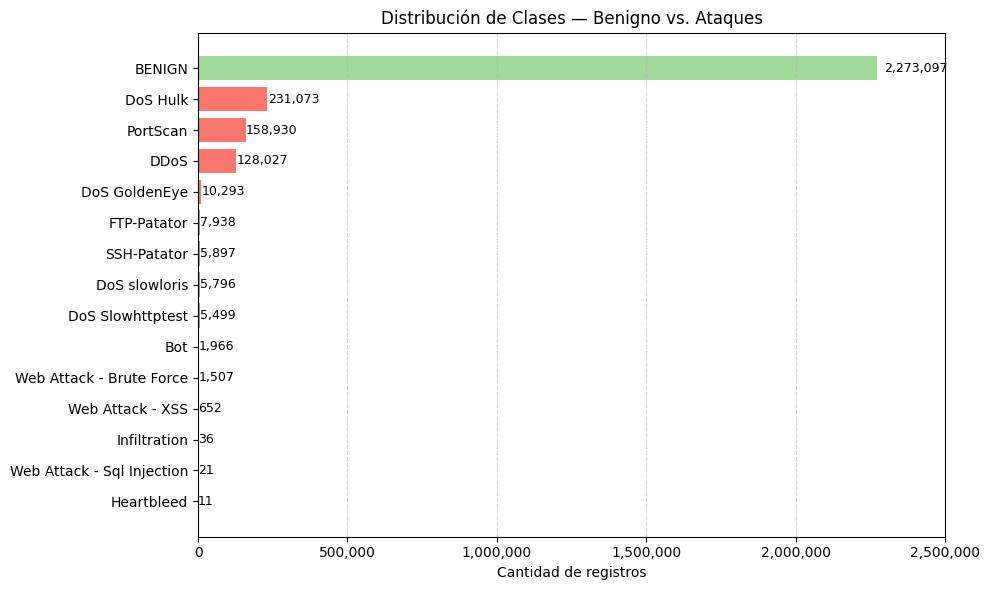

In [6]:
# Gráfico: distribución de clases
colors = [COLOR_BENIGNO if c == 'BENIGN' else COLOR_ATAQUE for c in counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(counts.index, counts.values, color=colors)

# Etiqueta con la cantidad al final de cada barra
for bar in bars:
    width = bar.get_width()
    ax.text(width * 1.01, bar.get_y() + bar.get_height() / 2,
            f'{width:,}', va='center', fontsize=9)

# Desactiva la notación científica por completo en el eje X
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
# Grilla tenue
ax.grid(True, which="both", axis="x", linestyle="--", alpha=0.5)

# Ajustar el límite de X
max_val = counts.values.max()
ax.set_xlim(0, max_val * 1.1)

ax.set_xlabel('Cantidad de registros')
ax.set_title('Distribución de Clases — Benigno vs. Ataques')
ax.invert_yaxis() # la clase más frecuente arriba
plt.tight_layout()
plt.show()

**Preguntas y Respuestas**

**¿Cuál es la variable objetivo?**
La variable objetivo es Label, que indica si el tráfico es benigno o un tipo especícico de ataque.

**¿Hay múltiples clases?**
Sí, es un problema multiclase, incluye beningn más 14 tipos de ataques distintos.

**¿Está balanceado el dataset?**
El dataset está desbalanceado, ya que la clase BENIGN representa el 80% de los datos. sto es un problema porque un modelo puede aprender a predecir "siempre BENIGN" y obtener un accuracy del 80% sin detectar ningún ataque.

**¿Qué ataques dominan?**
Los 3 ataques más frecuentes son: DoS Hulk, PortScan y DDoS. Mientras que Heartbleed, Web Attack-Sql Injection	o Infiltration son extremadamente raros.


##<font color="red">2.4 Obs: ¿Se puede agrupar clases?</font>

Sí, se puede. Vamos a agrupar por familia de ataque.

In [7]:
agrupacion = {
    'BENIGN': 'BENIGN',
    'DoS Hulk': 'DoS/DDoS',
    'DoS GoldenEye': 'DoS/DDoS',
    'DoS slowloris': 'DoS/DDoS',
    'DoS Slowhttptest': 'DoS/DDoS',
    'DDoS': 'DoS/DDoS',
    'PortScan': 'PortScan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Botnet',
    'Heartbleed': 'Rare Attack',
    'Infiltration': 'Rare Attack',
    'Web Attack-Brute Force': 'Web Attack',
    'Web Attack-XSS': 'Web Attack',
    'Web Attack-Sql Injection': 'Rare Attack',
}
df['Label2'] = df['Label'].map(agrupacion)

# Muestra la cantidad de registros por cada nueva clase
conteo_clases = df['Label2'].value_counts()
print("Cantidad por clase:")
print(conteo_clases)

Cantidad por clase:
Label2
BENIGN         2273097
DoS/DDoS        380688
PortScan        158930
Brute Force      13835
Botnet            1966
Rare Attack         47
Name: count, dtype: int64


##<font color="red">2.4 Obs: ¿Se puede agrupar clases? (corregido) </font>

Sí, se puede. Vamos a agrupar por familia de ataque.

In [8]:
agrupacion = {
    'BENIGN': 'BENIGN',
    'DoS Hulk': 'DoS/DDoS',
    'DoS GoldenEye': 'DoS/DDoS',
    'DoS slowloris': 'DoS/DDoS',
    'DoS Slowhttptest': 'DoS/DDoS',
    'DDoS': 'DoS/DDoS',
    'PortScan': 'PortScan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Botnet',
    'Heartbleed': 'Rare Attack',
    'Infiltration': 'Rare Attack',
    'Web Attack - Brute Force': 'Web Attack',
    'Web Attack - XSS': 'Web Attack',
    'Web Attack - Sql Injection': 'Rare Attack',
}
df['Label'] = df['Label'].map(agrupacion)

# Muestra la cantidad de registros por cada nueva clase
conteo_clases = df['Label'].value_counts()
print("Cantidad por clase:")
print(conteo_clases)

Cantidad por clase:
Label
BENIGN         2273097
DoS/DDoS        380688
PortScan        158930
Brute Force      13835
Web Attack        2159
Botnet            1966
Rare Attack         68
Name: count, dtype: int64


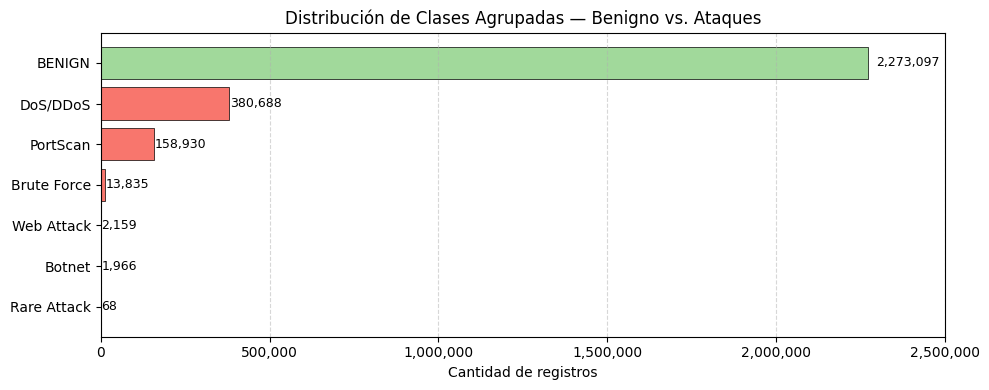

In [9]:
# Gráfico: distribución de clases por familia
counts = df['Label'].value_counts()
colors = [COLOR_BENIGNO if c == 'BENIGN' else COLOR_ATAQUE for c in counts.index]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.5)

# Etiqueta con la cantidad al final de cada barra
for bar in bars:
    width = bar.get_width()
    ax.text(width * 1.01, bar.get_y() + bar.get_height() / 2,
            f'{width:,}', va='center', fontsize=9)

# Desactiva la notación científica por completo en el eje X
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
# Grilla tenue
ax.grid(True, which="both", axis="x", linestyle="--", alpha=0.5)
# Ajustar el límite de X
max_val = counts.values.max()
ax.set_xlim(0, max_val * 1.1)

ax.set_xlabel('Cantidad de registros')
ax.set_title('Distribución de Clases Agrupadas — Benigno vs. Ataques')
ax.invert_yaxis()  # La clase más frecuente arriba
plt.tight_layout()
plt.show()

## 2.5 Estadísticas descriptivas

In [10]:
# Estadísticos completos

pd.set_option('display.float_format', '{:.2f}'.format) # Desactivar notación científica
pd.set_option('display.max_rows', None)

# Calcular estadísticos base
desc = df[num_cols].describe().T

# Métricas adicionales útiles para el EDA
desc['mediana'] = df[num_cols].median()
desc['sesgo'] = df[num_cols].skew()
desc['curtosis'] = df[num_cols].kurtosis()
desc['%_ceros'] = (df[num_cols] == 0).mean() * 100
desc['%_nan'] = df[num_cols].isnull().mean() * 100

# Ordenar por sesgo
desc_sorted = desc.sort_values('sesgo', ascending=False)

desc_sorted[['count', 'mean', 'mediana', 'std', 'min',
                    '25%', '75%', 'max', 'sesgo', 'curtosis',
                    '%_ceros', '%_nan']]

,count,mean,mediana,std,min,25%,75%,max,sesgo,curtosis,%_ceros,%_nan
Total Length of Fwd Packets,2830743.00,549.30,62.00,9993.59,0.00,12.00,187.00,12900000.00,805.57,988552.62,15.87,0.00
Subflow Fwd Bytes,2830743.00,549.29,62.00,9980.07,0.00,12.00,187.00,12870338.00,803.60,984882.53,15.87,0.00
act_data_pkt_fwd,2830743.00,5.42,1.00,636.43,0.00,0.00,2.00,213557.00,284.60,83076.67,34.02,0.00
Total Backward Packets,2830743.00,10.39,2.00,997.39,0.00,1.00,4.00,291922.00,244.68,62017.98,16.02,0.00
Subflow Bwd Packets,2830743.00,10.39,2.00,997.39,0.00,1.00,4.00,291922.00,244.68,62017.98,16.02,0.00
Subflow Fwd Packets,2830743.00,9.36,2.00,749.67,1.00,2.00,5.00,219759.00,244.38,61754.43,0.00,0.00
Total Fwd Packets,2830743.00,9.36,2.00,749.67,1.00,2.00,5.00,219759.00,244.38,61754.43,0.00,0.00
Subflow Bwd Bytes,2830743.00,16162.30,123.00,2263057.28,0.00,0.00,482.00,655453030.00,244.34,61604.20,25.00,0.00
Total Length of Bwd Packets,2830743.00,16162.64,123.00,2263088.05,0.00,0.00,482.00,655453030.00,244.33,61601.65,25.00,0.00
Fwd URG Flags,2830743.00,0.00,0.00,0.01,0.00,0.00,0.00,1.00,94.78,8981.50,99.99,0.00


In [11]:
# Guardar la tabla descriptiva
desc_sorted.to_csv(f'estadisticos_descriptivos.csv')
print('Tabla guardada.')

Tabla guardada.


**Preguntas y Respuestas**

* **Dispersión y variabilidad**

**¿Cómo se distribuyen las variables?**

Las variables presentan alta dispersión, distribuciones sesgadas (no normales) y valores extremos en varias columnas.

En variables como Total Length of Bwd Packets, la desviación estándar 2,263,088$ es significativamente superior a la media 16,162, lo que indica una variabilidad extrema. Además, la diferencia entre el valor mínimo 0 y el máximo 655,453,030 refuerza la existencia de datos muy heterogéneos.

Esta dispersión es natural en ciberseguridad, ya que el tráfico normal suele ser pequeño y constante, mientras que ciertos ataques o transferencias masivas generan esos picos extremos que disparan la desviación estándar.

**¿Qué variable presenta el mayor volumen de datos transmitidos en promedio?**

La variable Total Length of Bwd Packets con un promedio de 16,162 bytes por flujo, supera ampliamente a los paquetes enviados (Forward), que promedian 549.30 bytes.

* **Media vs. mediana**

**¿Cuál es la diferencia entre el promedio y la mediana en la variable Total Length of Bwd Packets?**

Hay una diferencia enorme, el promedio es 16,162.64 mientras que la mediana es solo 123.0. Esto indica una distribución extremadamente sesgada donde unos pocos flujos tienen tamaños gigantescos.

En datos de tráfico de red tan sesgados, la mediana describe mucho mejor lo que ocurre en la mayoría de las conexiones.

* **Sesgo y curtosis**

**¿Cómo se comporta el sesgo en el dataset?**

Todas las variables muestran un sesgo positivo alto (valores como 805.57 o 244.38). Esto confirma que la gran mayoría de las conexiones de red son pequeñas, pero existe una "cola" larga hacia la derecha de eventos con valores muy altos (posibles ataques o transferencias masivas).

**¿Qué indica el valor de curtosis tan elevado en variables como Total Length of Fwd Packets?**

La curtosis de 988,552.61 indica una distribución "Leptocúrtica" extrema. Esto significa que los datos tienen una concentración altísima en un punto y presentan valores atípicos (outliers) muy severos y frecuentes.

**¿Qué indican un sesgo y curtosis alto?**

Cuando una variable tiene sesgo alto y curtosis alta al mismo tiempo, como ocurre en la mayoría de las variables de este dataset, significa que hay muchísimas conexiones pequeñas y normales, más unos pocos eventos extremos muy alejados del resto. Para un IDS, esos eventos extremos son exactamente los que queremos detectar.

**¿Qué relación hay entre el sesgo de las variables y el desbalance de clases?**

Ambos fenómenos están relacionados. Como BENIGN representa el 80% del dataset, la mayoría de los registros corresponden a tráfico normal con valores pequeños y estables. Los ataques, aunque pocos en cantidad, generan los valores extremos que producen el sesgo positivo. Si el dataset estuviera balanceado, el sesgo sería menor porque habría más registros con valores altos.

* **Ceros y nulos**

**¿Qué variable tiene la mayor cantidad de valores en cero y qué significa esto?**

La variable Fwd URG Flags tiene un 99.98% de ceros. En ciberseguridad, esto es normal ya que las "flags" de urgencia no se usan con frecuencia en el tráfico común; su aparición podría ser un indicador importante para detectar tipos específicos de anomalías o escaneos.

**¿Existe presencia de valores nulos en las variables analizadas?**

Según la columna %_nan, todas las variables mostradas tienen un 0.0% de valores nulos, vamos a profundizar en el análisis para confirmar.

## 2.6 Detección y Tratamiento de Valores infinitos

In [12]:
# Ver columnas con valores infinitos
inf_por_columna = np.isinf(df[num_cols]).sum()
inf_detectados  = inf_por_columna[inf_por_columna > 0]

print(f'Columnas con valores infinitos: {len(inf_detectados)}')
print(inf_detectados)

Columnas con valores infinitos: 2
Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64


In [13]:
#Reemplazar loa valores infinitos por NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print('Valores infinitos reemplazados por NaN.')

Valores infinitos reemplazados por NaN.


## 2.7 Valores faltantes (NaN)

In [14]:
# Mostrar columnas con NaN
nan_counts = df.isnull().sum()
nan_cols = nan_counts[nan_counts > 0]

print(f'Columnas con NaN: {len(nan_cols)}')
print(nan_cols)
print(f'\nTotal de NaN en el dataset: {nan_cols.sum():,}')
print(f'Representan el {nan_cols.sum() / df.size * 100:.4f}% del total de celdas.')

Columnas con NaN: 3
Flow Bytes/s      2867
Flow Packets/s    2867
Label2            2180
dtype: int64

Total de NaN en el dataset: 7,914
Representan el 0.0035% del total de celdas.


<Axes: >

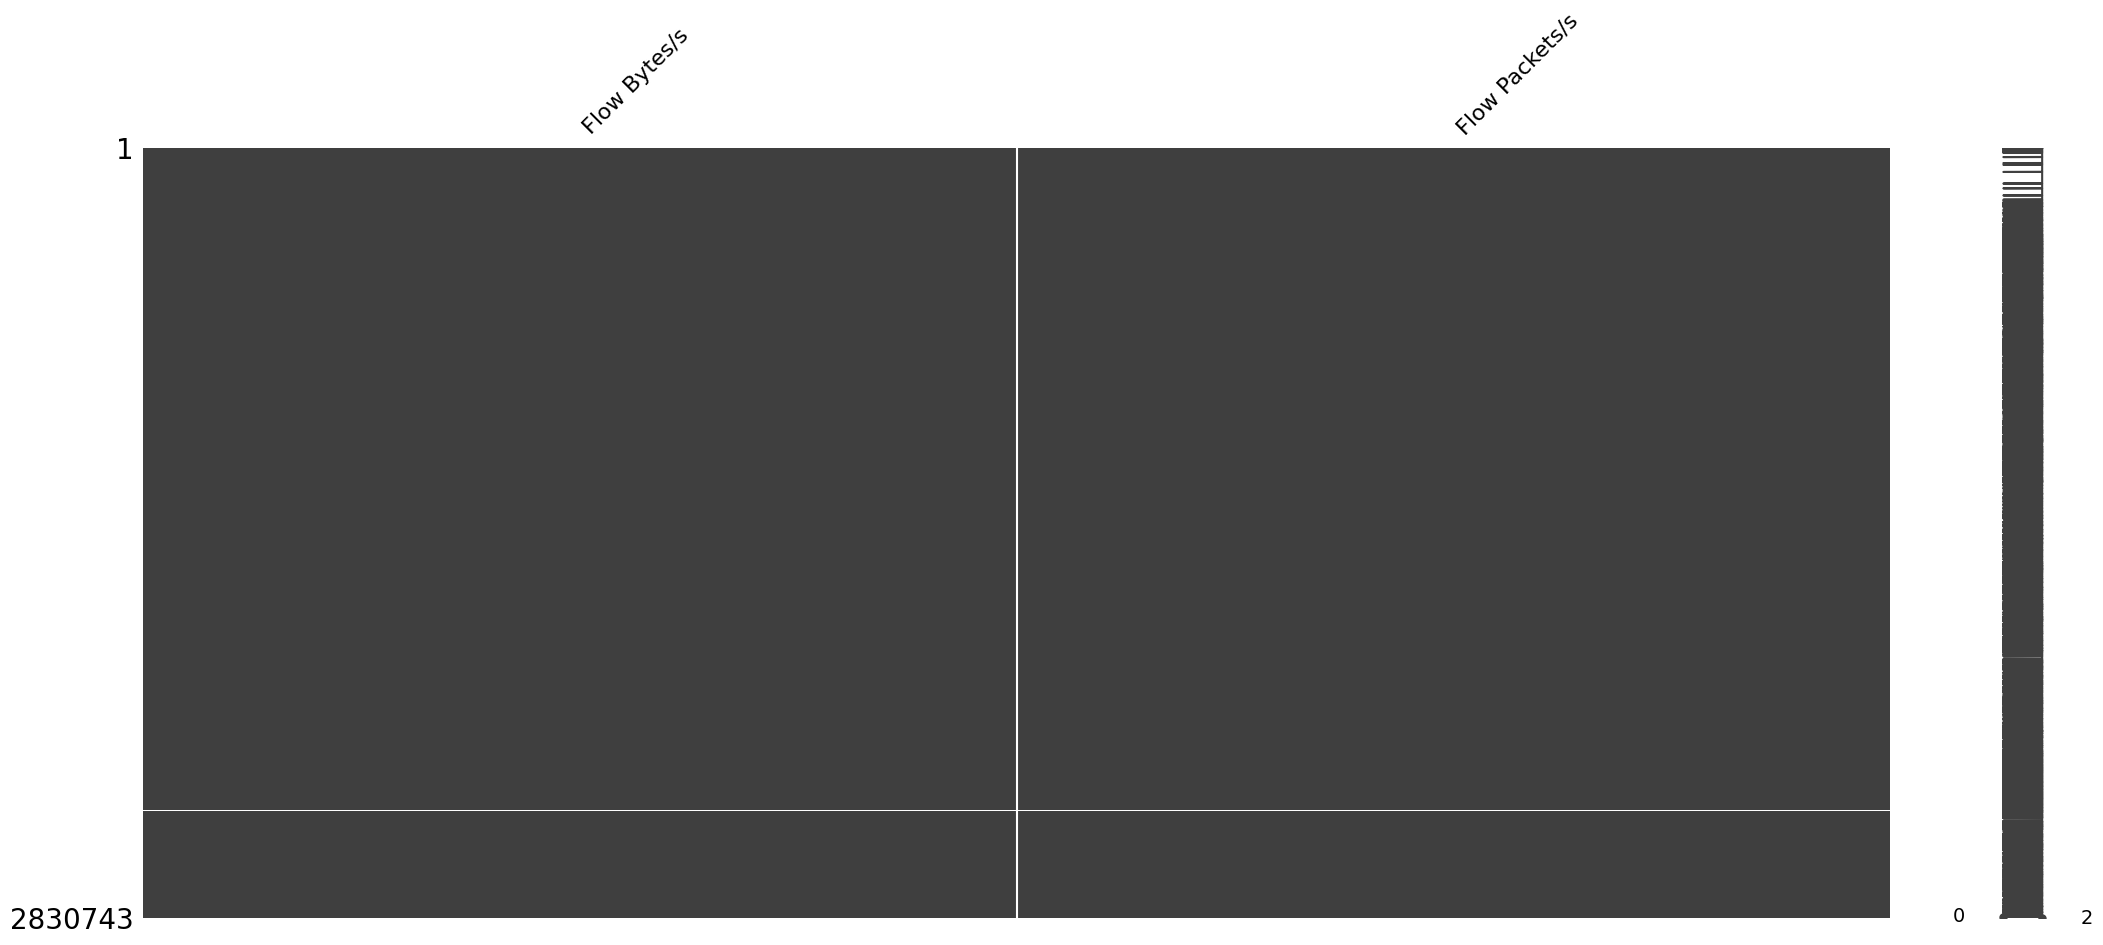

In [15]:
# Visualizar la ubicación de los NaN
msno.matrix(df[['Flow Bytes/s', 'Flow Packets/s']])

**Preguntas y Respuestas**

**¿Hay valores raros?**

Sí, existen valores infinitos (np.inf) en variables como: Flow Bytes/s y Flow Packets/s.
Estos deben tratarse antes de modelar.


**¿Hay valores faltantes?**

Sí, existen valores faltantes de la variable Flow Bytes/s y Flow Packets/s.

**¿Qué tipo son?**

Son MNAR (Missing Not At Random): los NaN aparecen porque Flow Duration es igual a 0 en esos registros, y al calcular una tasa (Bytes ÷ Duración) se produce una división por cero. Es decir, el valor falta a causa de otro valor del mismo registro, no por azar. Que ambas columnas tengan exactamente los mismos 2.867 nulos confirma que comparten la misma causa raíz.

**¿Qué estrategia de limpieza se justifica?**

Dado que representan solo el 0.0026% del dataset, la estrategia más eficiente y segura es la eliminación de estos registros (dropping), ya que no se pierde información significativa y se evita introducir sesgos mediante imputaciones en variables de red tan sensibles.



##<font color="red">2.7 Obs: ¿Ese 0.0026% corresponde a los ataques? Separar para luego analizar.</font>

In [16]:
# Identificar las filas con NaN antes de eliminarlas
mask_nan = df['Flow Bytes/s'].isnull() | df['Flow Packets/s'].isnull()
df_nan_rows = df[mask_nan]

# Distribución por clase de las filas con NaN
print("Composición de las filas con NaN")
print(f"Total filas con NaN: {mask_nan.sum():,}")
print()
dist_nan = df_nan_rows['Label'].value_counts()
pct_nan  = dist_nan / dist_nan.sum() * 100
tabla_nan = pd.DataFrame({'Cantidad': dist_nan, '% del NaN': pct_nan.round(2)})
print(tabla_nan.to_string())

# ¿Qué % de cada clase se pierde?
print("\nImpacto por clase: % de registros perdidos:")
total_por_clase = df['Label'].value_counts()
for clase in dist_nan.index:
    perdidos = dist_nan[clase]
    total    = total_por_clase[clase]
    print(f"{clase}: pierde {perdidos} de {total} ({perdidos/total*100:.2f}%)")

Composición de las filas con NaN
Total filas con NaN: 2,867

             Cantidad  % del NaN
Label                           
BENIGN           1777      61.98
DoS/DDoS          951      33.17
PortScan          126       4.39
Botnet             10       0.35
Brute Force         3       0.10

Impacto por clase: % de registros perdidos:
BENIGN: pierde 1777 de 2273097 (0.08%)
DoS/DDoS: pierde 951 de 380688 (0.25%)
PortScan: pierde 126 de 158930 (0.08%)
Botnet: pierde 10 de 1966 (0.51%)
Brute Force: pierde 3 de 13835 (0.02%)


**Preguntas y Respuestas**

**¿Ese 0.0026% corresponde a los ataques?**

Sí, el 38.02% de las filas con NaN son ataques (1.090 registros distribuidos en 5 tipos de ataque) y el 61.98% son tráfico benigno (1.777 registros).

La eliminación de estas filas queda justificada porque:
* **Impacto mínimo**: Ninguna clase pierde más del 0.51% de sus registros. Crucialmente, las clases más raras y difíciles de detectar (Heartbleed, Infiltration, Web Attack-Sql Injection) no tienen ningún NaN, por lo que no se pierde ni un solo ejemplo de las clases más valiosas.

* **Motivo técnico**: Los valores NaN se originan por un Flow Duration = 0. Imputar datos mediante estadísticas como la mediana carece de sentido físico, ya que es imposible calcular tasas de red sin duración.

In [17]:
# Decisión: eliminar filas con NaN
filas_antes  = len(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
filas_despues = len(df)

print(f'Filas eliminadas: {filas_antes - filas_despues:,}')
print(f'Dataset final: {filas_despues:,} filas')
print(f'NaN restantes: {df.isnull().sum().sum()}')

Filas eliminadas: 5,047
Dataset final: 2,825,696 filas
NaN restantes: 0


## 2.8 Análisis de Outliers

In [18]:
# Método IQR para detectar outliers
Q1  = df[num_cols].quantile(0.25)
Q3  = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_count = ((df[num_cols] < limite_inferior) | (df[num_cols] > limite_superior)).sum()
outliers_pct = (outliers_count / len(df) * 100).round(2)

outliers_df = pd.DataFrame({
    'n_outliers': outliers_count,
    'pct_outliers': outliers_pct
}).sort_values('pct_outliers', ascending=False)

print(outliers_df.head(20).to_string())
print(f'\nVariables con > 10% outliers: {(outliers_pct > 10).sum()}')
print(f'Variables con > 20% outliers: {(outliers_pct > 20).sum()}')

                             n_outliers  pct_outliers
Fwd IAT Mean                     671096         23.75
Fwd IAT Max                      665359         23.55
Fwd IAT Total                    664546         23.52
Fwd Packet Length Std            663770         23.49
Fwd IAT Std                      659736         23.35
Fwd Packet Length Max            654097         23.15
Bwd Packet Length Std            653829         23.14
Packet Length Variance           653868         23.14
Bwd Packet Length Max            636905         22.54
Destination Port                 625966         22.15
Max Packet Length                623352         22.06
Subflow Bwd Bytes                618969         21.91
Total Length of Bwd Packets      618969         21.91
Flow IAT Std                     599286         21.21
Bwd IAT Std                      598334         21.17
Flow IAT Mean                    572421         20.26
Idle Max                         567283         20.08
Bwd IAT Max                 

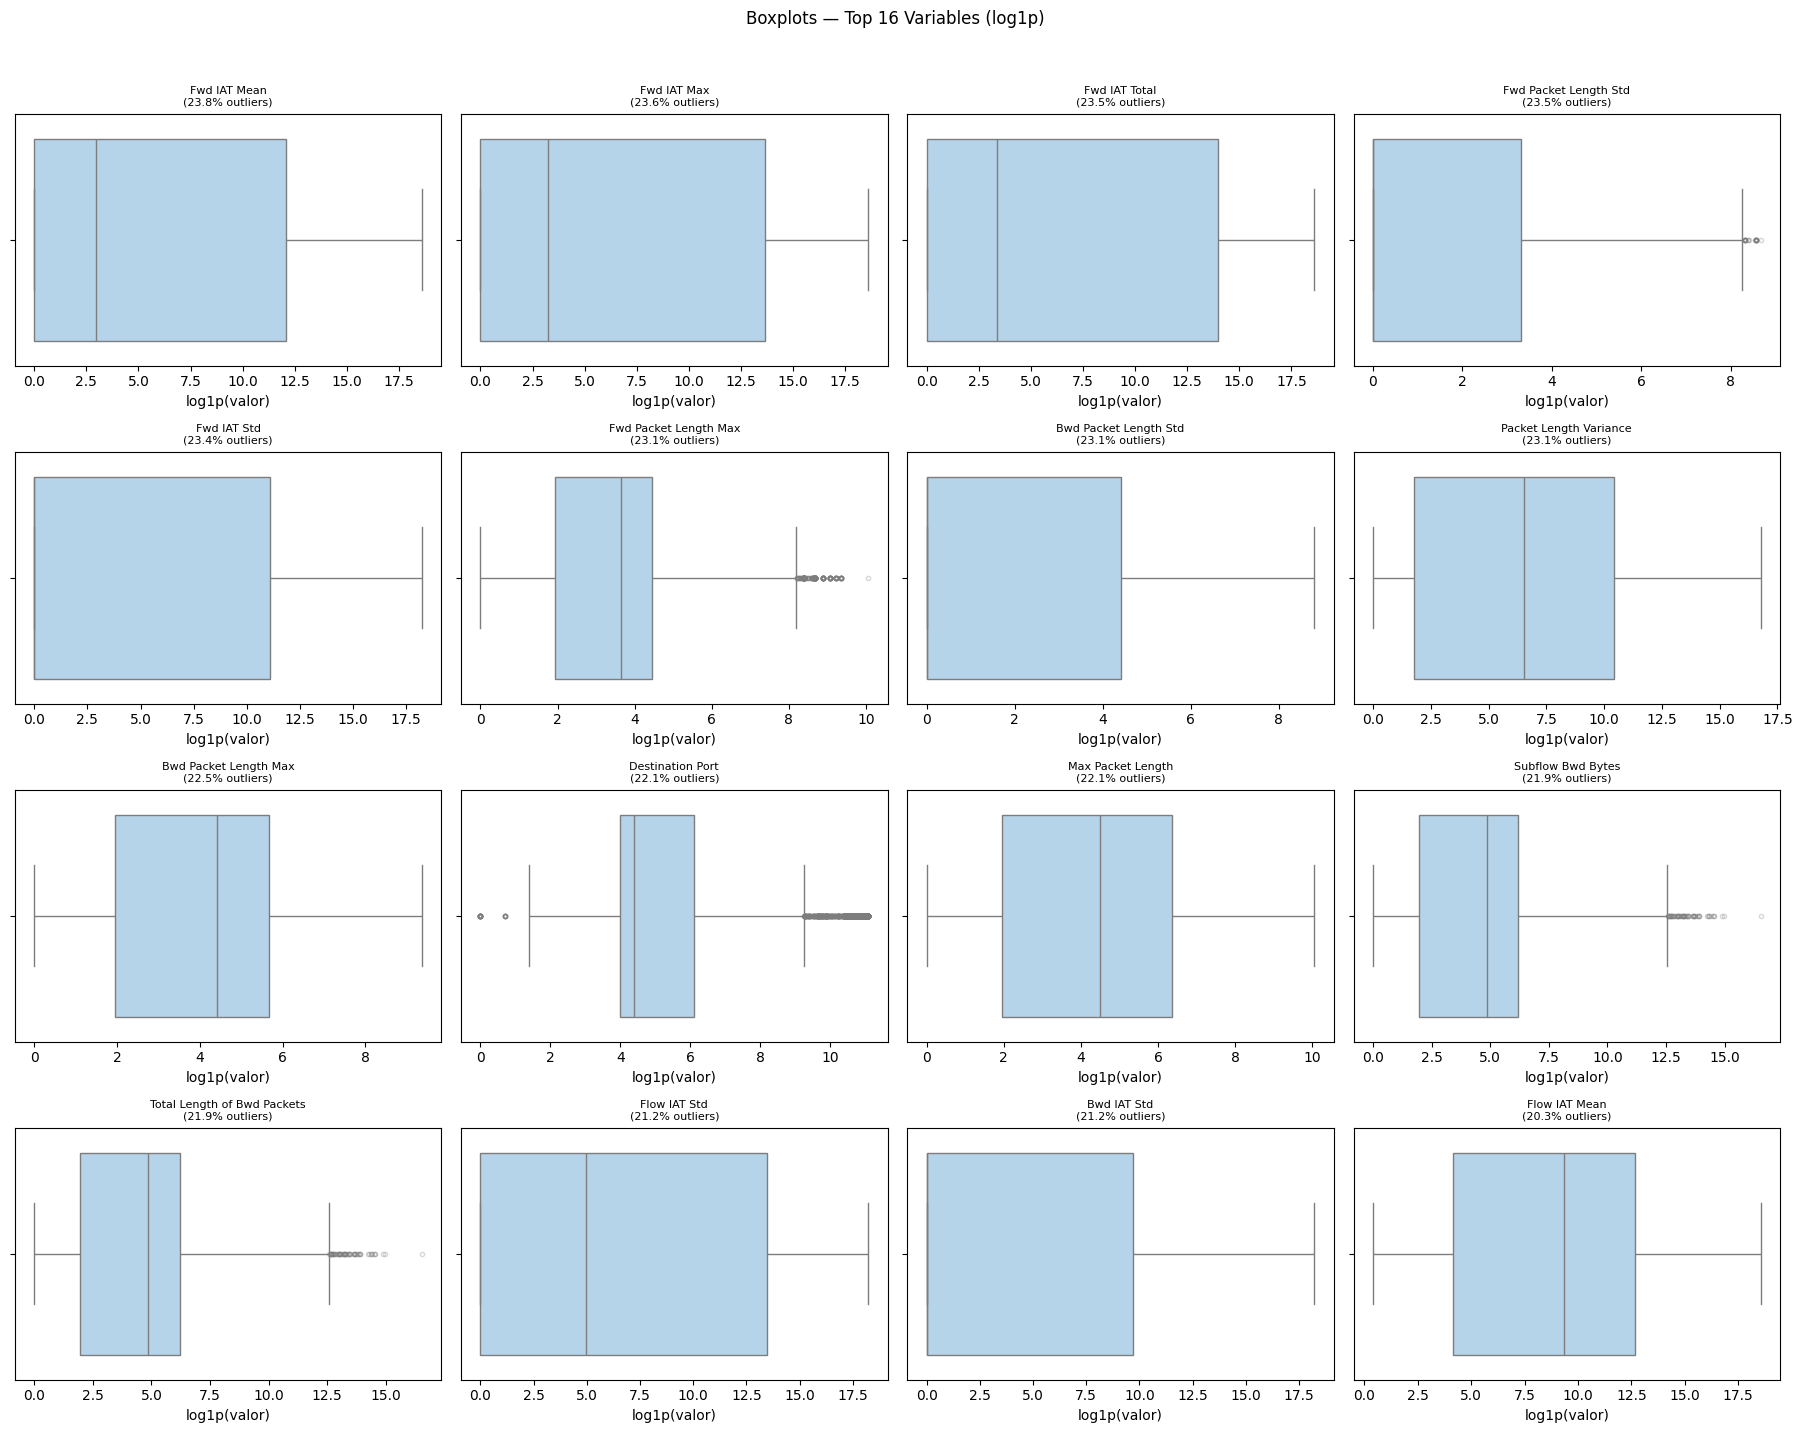

In [19]:
# Visualizamos las 16 con mayor proporción de outliers

# Preparación compacta de datos
cols = outliers_df.head(16).index.tolist()
muestra = df[num_cols].sample(min(30000, len(df)), random_state=42).apply(np.log1p)

# Configuración del gráfico con Seaborn
plt.figure(figsize=(18, 14))
for i, col in enumerate(cols):
    ax = plt.subplot(4, 4, i + 1)
    sns.boxplot(data=muestra[col], orient='h', color=COLOR_NEUTRO,
                flierprops={'marker': '.', 'alpha': 0.3})

    ax.set_title(f"{col}\n({outliers_pct[col]:.1f}% outliers)", fontsize=8)
    ax.set(xlabel='log1p(valor)')

plt.suptitle('Boxplots — Top 16 Variables (log1p)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Preguntas y Respuestas**

**¿Qué son los outliers en este contexto?**

Son flujos de red con valores extremadamente altos o bajos en alguna métrica. En redes, un ataque DoS genera millones de paquetes por segundo deliberadamente, así que los "outliers" no son errores sino señales de ataque.

**¿Cuántas variables tienen outliers significativos?**

La mayoría de las 78 variables presentan outliers, con varias superando el 20 % de sus valores fuera del rango IQR.

**¿Los eliminamos?**

No, los outliers son **información valiosa**, no ruido. Eliminarlos podría borrar justamente los patrones que distinguen un ataque del tráfico normal.

# 3. Limpieza y Calidad del Dataset

## 3.1 Detección de Variables Problemáticas

In [20]:
# Variables constantes (varianza = 0)
# Si una columna tiene el mismo valor en todas las filas, no aporta nada al modelo
rango = df[num_cols].max() - df[num_cols].min()
constantes = rango[rango == 0].index.tolist()

print(f'Variables constantes encontradas: {len(constantes)}')
for col in constantes:
    print(f' {col}: valor único = {df[col].unique()[0]}')

Variables constantes encontradas: 8
 Bwd PSH Flags: valor único = 0
 Bwd URG Flags: valor único = 0
 Fwd Avg Bytes/Bulk: valor único = 0
 Fwd Avg Packets/Bulk: valor único = 0
 Fwd Avg Bulk Rate: valor único = 0
 Bwd Avg Bytes/Bulk: valor único = 0
 Bwd Avg Packets/Bulk: valor único = 0
 Bwd Avg Bulk Rate: valor único = 0


In [21]:
# Variables con alta proporción de ceros (>50 %)
pct_ceros = (df[num_cols] == 0).mean() * 100
muchos_ceros = pct_ceros[pct_ceros > 50].sort_values(ascending=False)

print(f'Variables con > 50 % de ceros: {len(muchos_ceros)}')
print(muchos_ceros.to_string())

Variables con > 50 % de ceros: 31
Bwd PSH Flags           100.00
Bwd URG Flags           100.00
Bwd Avg Packets/Bulk    100.00
Fwd Avg Bulk Rate       100.00
Bwd Avg Bytes/Bulk      100.00
Fwd Avg Bytes/Bulk      100.00
Fwd Avg Packets/Bulk    100.00
Bwd Avg Bulk Rate       100.00
CWE Flag Count           99.99
Fwd URG Flags            99.99
RST Flag Count           99.98
ECE Flag Count           99.98
FIN Flag Count           96.47
Fwd PSH Flags            95.36
SYN Flag Count           95.36
Active Std               92.73
Idle Std                 91.89
URG Flag Count           90.52
Active Max               80.22
Active Min               80.22
Active Mean              80.22
Idle Max                 79.92
Idle Mean                79.92
Idle Min                 79.92
Bwd Packet Length Std    71.55
Bwd IAT Std              71.29
PSH Flag Count           70.22
ACK Flag Count           68.45
Fwd Packet Length Std    65.33
Fwd IAT Std              62.75
Bwd Packet Length Min    50.73


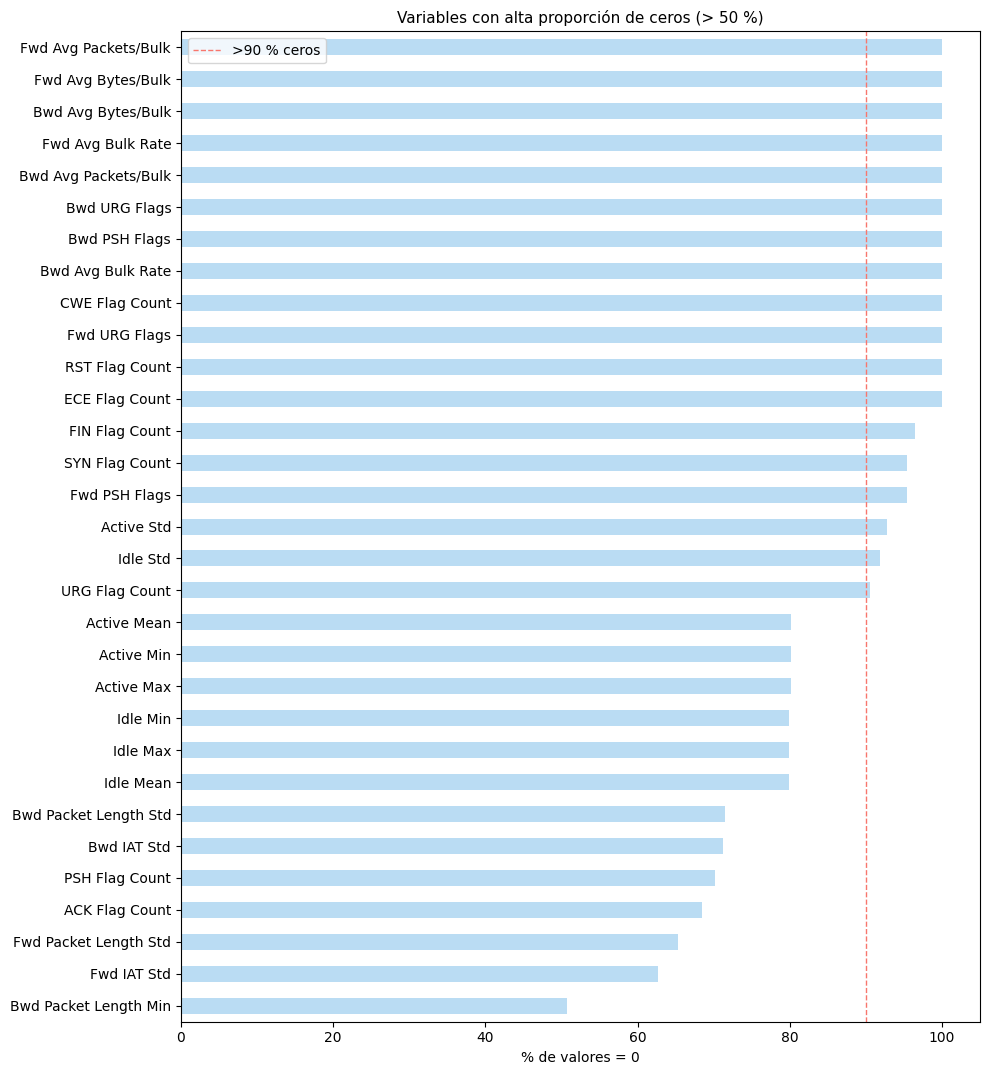

In [22]:
# Visualización: Variables con muchos ceros
if not muchos_ceros.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(muchos_ceros) * 0.35)))
    muchos_ceros.sort_values().plot(kind='barh', ax=ax, color=COLOR_NEUTRO, alpha=0.85)
    ax.axvline(x=90, color=COLOR_ATAQUE, linestyle='--', linewidth=1, label='>90 % ceros')
    ax.set_xlabel('% de valores = 0')
    ax.set_title('Variables con alta proporción de ceros (> 50 %)', fontsize=11)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [23]:
# Variables con valores negativos inesperados
# En tráfico de red: duración, bytes y paquetes nunca deben ser negativos

negativos = {}
for col in num_cols:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        negativos[col] = {'n_negativos': n_neg, 'valor_min': df[col].min()}

print('Variables con valores negativos:')
if negativos:
    print(pd.DataFrame(negativos).T.to_string())
else:
    print('Ninguna variable tiene valores negativos.')

Variables con valores negativos:
                         n_negativos       valor_min
Flow Duration                 115.00          -13.00
Flow Bytes/s                   85.00   -261000000.00
Flow Packets/s                115.00     -2000000.00
Flow IAT Mean                 115.00          -13.00
Flow IAT Max                  115.00          -13.00
Flow IAT Min                 2890.00          -14.00
Fwd IAT Min                    17.00          -12.00
Fwd Header Length              35.00 -32212234632.00
Bwd Header Length              22.00  -1073741320.00
Fwd Header Length.1            35.00 -32212234632.00
Init_Win_bytes_forward    1001172.00           -1.00
Init_Win_bytes_backward   1439655.00           -1.00
min_seg_size_forward           35.00   -536870661.00


In [24]:
# Columnas duplicadas (mismo hash de contenido)
hashes_cols = {}
duplicados_encontrados = []

for col in num_cols:
    # Usamos el hash de los bytes del array para comparación rápida
    h = hash(df[col].values.tobytes())
    if h in hashes_cols:
        duplicados_encontrados.append((hashes_cols[h], col))
        print(f'Idénticas: "{hashes_cols[h]}"  ==  "{col}"')
    else:
        hashes_cols[h] = col

if not duplicados_encontrados:
    print('No se encontraron columnas con valores exactamente iguales.')

Idénticas: "Bwd PSH Flags"  ==  "Bwd URG Flags"
Idénticas: "Fwd PSH Flags"  ==  "SYN Flag Count"
Idénticas: "Fwd URG Flags"  ==  "CWE Flag Count"
Idénticas: "Fwd Header Length"  ==  "Fwd Header Length.1"
Idénticas: "Bwd PSH Flags"  ==  "Fwd Avg Bytes/Bulk"
Idénticas: "Bwd PSH Flags"  ==  "Fwd Avg Packets/Bulk"
Idénticas: "Bwd PSH Flags"  ==  "Fwd Avg Bulk Rate"
Idénticas: "Bwd PSH Flags"  ==  "Bwd Avg Bytes/Bulk"
Idénticas: "Bwd PSH Flags"  ==  "Bwd Avg Packets/Bulk"
Idénticas: "Bwd PSH Flags"  ==  "Bwd Avg Bulk Rate"
Idénticas: "Total Fwd Packets"  ==  "Subflow Fwd Packets"
Idénticas: "Total Backward Packets"  ==  "Subflow Bwd Packets"


**Conclusiones del Análisis**

Tenemos los siguientes problemas críticos que afectan la calidad de los datos para el entrenamiento de un modelo:

* **Redundancia Absoluta (Varianza Cero)**: Existen 8 columnas constantes (como Bwd PSH Flags y Fwd Avg Bulk Rate) que contienen el mismo valor 0 en todas las filas.  
* **Alta Proporción de Ceros**: Existen 31 variables donde más del 50% de los datos son ceros.
* **Inconsistencias Físicas (Valores Negativos)**: Existen valores negativos en variables donde no debería, como Flow Duration (duración), Flow Bytes/s y Header Length, esto sugiere errores de medición.  
* **Columnas duplicadas**: Existen varias columnas idénticas entre sí, como Fwd PSH Flags y SYN Flag Count, o las versiones duplicadas de Fwd Header Length.

## <font color="red">3.2 Obs: Probar con todas las variables y las seleccionadas. Ver en crear nuevas variables, como por ejemplo agregar variables flags 'Error en XXX '</font>

**Estrategia:**  
1. Crear flags de anomalías técnicas de red (variables binarias 0/1)  
2. Evaluar utilidad discriminativa de cada flag (tasa de ataques en filas con flag=1 vs. baseline)  
3. Conservar solo las flags informativas  
4. En la sección de modelado comparar: todas las variables vs. seleccionadas por ANOVA vs. PCA

In [25]:
# Crear variables indicadoras de anomalías de red

# Flag 1: duración negativa o cero (físicamente imposible en un flujo real)
df['flag_duracion_invalida'] = (df['Flow Duration'] <= 0).astype(int)

# Flag 2: ratio paquetes fwd/bwd extremo (posible DoS unidireccional)
ratio = df['Total Fwd Packets'] / (df['Total Backward Packets'] + 1)
df['flag_ratio_extremo'] = (ratio > 100).astype(int)

# Flag 3: longitud de paquete anómalamente grande
if 'Max Packet Length' in df.columns:
    q99 = df['Max Packet Length'].quantile(0.99)
    df['flag_paquete_gigante'] = (df['Max Packet Length'] > q99).astype(int)

# Flag 4: flags TCP simultáneas inusuales (SYN+FIN al mismo tiempo = ataque)
if 'SYN Flag Count' in df.columns and 'FIN Flag Count' in df.columns:
    df['flag_syn_fin_juntos'] = (
        (df['SYN Flag Count'] > 0) & (df['FIN Flag Count'] > 0)
    ).astype(int)

# Flag 5: flujo con muchos paquetes pero cero bytes (posible escaneo)
if 'Total Fwd Packets' in df.columns and 'Total Length of Fwd Packets' in df.columns:
    df['flag_paquetes_vacios'] = (
        (df['Total Fwd Packets'] > 10) &
        (df['Total Length of Fwd Packets'] == 0)
    ).astype(int)

# Flag 6: IAT (inter-arrival time) de paquetes extremadamente bajo
# Ataques de fuerza bruta o DoS envían paquetes tan rápido como pueden
if 'Flow IAT Mean' in df.columns:
    p01 = df['Flow IAT Mean'].quantile(0.01)
    df['flag_iat_muy_bajo'] = (df['Flow IAT Mean'] <= p01).astype(int)

# Resumen de las nuevas variables
nuevas_flags = [c for c in df.columns if c.startswith('flag_')]
print(f"\nVariables flag creadas: {len(nuevas_flags)}")
for f in nuevas_flags:
    pct = df[f].mean() * 100
    print(f"  {f}: {df[f].sum():,} registros ({pct:.3f}%)")

# Verificar si las flags se asocian con ataques
print("\nTasa de ataques en registros con cada flag")
for f in nuevas_flags:
    sub = df[df[f] == 1]
    tasa_ataque = (sub['Label'] != 'BENIGN').mean() * 100
    print(f"  {f}: {tasa_ataque:.1f}% son ataques")


Variables flag creadas: 6
  flag_duracion_invalida: 115 registros (0.004%)
  flag_ratio_extremo: 1,196 registros (0.042%)
  flag_paquete_gigante: 21,863 registros (0.774%)
  flag_syn_fin_juntos: 0 registros (0.000%)
  flag_paquetes_vacios: 1,701 registros (0.060%)
  flag_iat_muy_bajo: 31,531 registros (1.116%)

Tasa de ataques en registros con cada flag
  flag_duracion_invalida: 0.0% son ataques
  flag_ratio_extremo: 0.0% son ataques
  flag_paquete_gigante: 89.4% son ataques
  flag_syn_fin_juntos: nan% son ataques
  flag_paquetes_vacios: 0.2% son ataques
  flag_iat_muy_bajo: 32.2% son ataques


Resultado del análisis de flags:
- flag_duracion_invalida: no discrimina (0.0% son ataques) → DESCARTAR
- flag_ratio_extremo: no discrimina (0.0% ataques) → DESCARTAR
- flag_syn_fin_juntos: variable constante (0 registros positivos) → DESCARTAR  
- flag_paquetes_vacios: contraproducente (0.2% son ataques) → DESCARTAR
- flag_iat_muy_bajo: útil (32.2% son ataques vs 20% del baseline del dataset) → CONSERVAR

  Captura el comportamiento de DoS y Brute Force, que envían paquetes al máximo ritmo posible.

- flag_paquete_gigante: el más potente (89.4% son ataques) → CONSERVAR

  Con 21.863 registros tiene masa suficiente para que el modelo aprenda el patrón sólidamente.
  Es la variable flag más discriminativa de todas las creadas.
   

In [26]:
# Resumen
flags_utiles = ['flag_iat_muy_bajo', 'flag_paquete_gigante']
flags_descartar = ['flag_duracion_invalida', 'flag_ratio_extremo',
                   'flag_syn_fin_juntos', 'flag_paquetes_vacios']

df = df.drop(columns=flags_descartar)
print(f"Variables flag conservadas: {flags_utiles}")
print(f"flag_iat_muy_bajo: 32.2% ataques (1.6x el baseline)")
print(f"flag_paquete_gigante: 89.4% ataques (4.5x el baseline)")

Variables flag conservadas: ['flag_iat_muy_bajo', 'flag_paquete_gigante']
flag_iat_muy_bajo: 32.2% ataques (1.6x el baseline)
flag_paquete_gigante: 89.4% ataques (4.5x el baseline)


## 3.3 Eliminación de Columnas Problemáticas

**Estrategia:**

1. Eliminar Columnas Constantes
2. Columnas Duplicadas: vamos a quedarnos con una sola versión de los pares idénticos.
3. Variables con Valores Negativos Críticos.

In [27]:
# Consolidar columnas a eliminar por categoría
cols_constantes = constantes # Las 8 identificadas con rango cero

cols_duplicadas = [
    'Fwd Header Length.1',
    'Subflow Fwd Packets',
    'Subflow Bwd Packets',
    'SYN Flag Count',
    'CWE Flag Count'
]
# Eliminamos las que tienen errores de medición graves
cols_corruptas = [
    'Fwd Header Length',
    'Bwd Header Length'
]

to_drop = list(set(cols_constantes + cols_duplicadas + cols_corruptas))

# Eliminar solo las que existen en el DataFrame
to_drop_exist = [c for c in to_drop if c in df.columns]
df_clean = df.drop(columns=to_drop_exist)

# Actualizar lista de columnas numéricas
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

print(f'Limpieza completada.')
print(f' Columnas originales: {df.shape[1]}')
print(f' Columnas eliminadas: {len(to_drop_exist)}')
print(f' Columnas restantes: {df_clean.shape[1]}')
print(f' Columnas numéricas: {len(num_cols)}')
print(f' Flags conservadas: {[c for c in num_cols if c.startswith("flag_")]}')
print(f'\nDataset limpio: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas')

Limpieza completada.
 Columnas originales: 82
 Columnas eliminadas: 15
 Columnas restantes: 67
 Columnas numéricas: 65
 Flags conservadas: ['flag_paquete_gigante', 'flag_iat_muy_bajo']

Dataset limpio: 2,825,696 filas × 67 columnas


# 4. Análisis Exploratorio Profundo (EDA)

A partir de aquí usamos `df_clean`. Al reiniciar la sesión, debemos ejecutar todas las celdas desde el inicio.

In [28]:
# Verificar que df_clean está en memoria
if 'df_clean' not in dir():
    print('ERROR: df_clean no está en memoria. Ejecutá todas las celdas desde la sección 2.')
else:
    num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
    print(f'df_clean en memoria: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas')

df_clean en memoria: 2,825,696 filas × 67 columnas


## 4.1 Distribución de Clases

In [29]:
# Tabla de distribución con conteo y porcentaje
counts = df_clean['Label'].value_counts()
pcts = counts / len(df_clean) * 100

tabla = pd.DataFrame({
    'Cantidad': counts,
    'Porcentaje (%)': pcts.round(3),
    'Tipo': ['Benigno' if c == 'BENIGN' else 'Ataque' for c in counts.index]
})
print(tabla.to_string())

             Cantidad  Porcentaje (%)     Tipo
Label                                         
BENIGN        2271320           80.38  Benigno
DoS/DDoS       379737           13.44   Ataque
PortScan       158804            5.62   Ataque
Brute Force     13832            0.49   Ataque
Botnet           1956            0.07   Ataque
Rare Attack        47            0.00   Ataque


## 4.2 ¿Cuánto dura cada Tipo de Ataque? (Flow Duration)

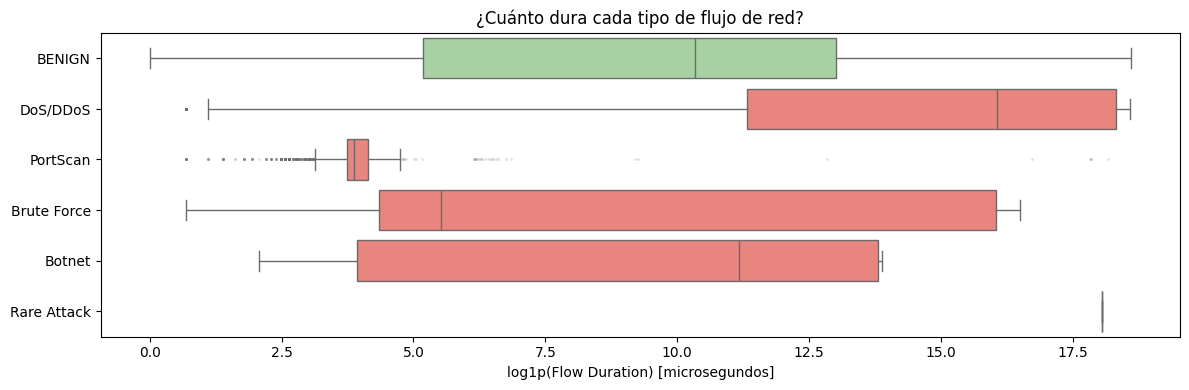

In [30]:
# Boxplot de duración por clase (escala log)
muestra = df_clean.sample(min(50_000, len(df_clean)), random_state=42).copy()
muestra['log_duration'] = np.log1p(muestra['Flow Duration'].clip(lower=0))

orden = df_clean['Label'].value_counts().index
colors_list = [COLOR_BENIGNO if c == 'BENIGN' else COLOR_ATAQUE for c in orden]

fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=muestra, x='log_duration', y='Label', order=orden,
                palette=dict(zip(orden, colors_list)),
                flierprops={'marker':'.','alpha':0.2,'markersize':2})
ax.set_xlabel('log1p(Flow Duration) [microsegundos]')
ax.set_ylabel('')
ax.set_title('¿Cuánto dura cada tipo de flujo de red?')
plt.tight_layout()
plt.show()

**Preguntas y Respuestas**

**¿Cómo varía la duración del flujo según el tipo de ataque?**

Cada grupo de ataque muestra un perfil de duración distinto. DoS/DDoS genera flujos notablemente largos (caja desplazada hacia la derecha), lo que refleja conexiones sostenidas que buscan agotar los recursos del servidor. PortScan en cambio produce flujos muy cortos y concentrados, ya que solo sondea puertos sin establecer una conexión real. Brute Force tiene la mayor variabilidad de todos los grupos, con una caja muy ancha que indica intentos que van desde conexiones instantáneas hasta sesiones prolongadas de prueba de credenciales.

**¿Todos los ataques tienen un patrón claro?**

No. PortScan es el más fácil de separar: su caja es muy compacta y está claramente por debajo del rango de BENIGN. DoS/DDoS también es distinguible porque sus duraciones son sistemáticamente más altas. Sin embargo, Botnet y Brute Force se solapan considerablemente con BENIGN, lo que significa que la duración sola no alcanza para detectarlos y el modelo necesitará combinar esta variable con otras.

**¿Qué clases son más fáciles de separar visualmente?**

PortScan es la clase más separable por duración: su distribución es compacta y claramente diferente al resto. DoS/DDoS también se distingue bien por sus valores altos. Botnet y BENIGN en cambio tienen distribuciones muy similares, lo que anticipa que serán las clases con peor recall en el modelo.

**¿Qué nos dice Rare Attack?**

Rare Attack (Heartbleed, Infiltration, Web Attack-Sql Injection agrupados) muestra casi una línea sin caja visible, lo que indica que tiene muy pocos registros y duraciones extremadamente variables. Esto confirma que estas clases son las más difíciles de modelar y que necesitarán tratamiento especial con SMOTE o peso de clase aumentado.

## 4.3 Correlación entre Variables

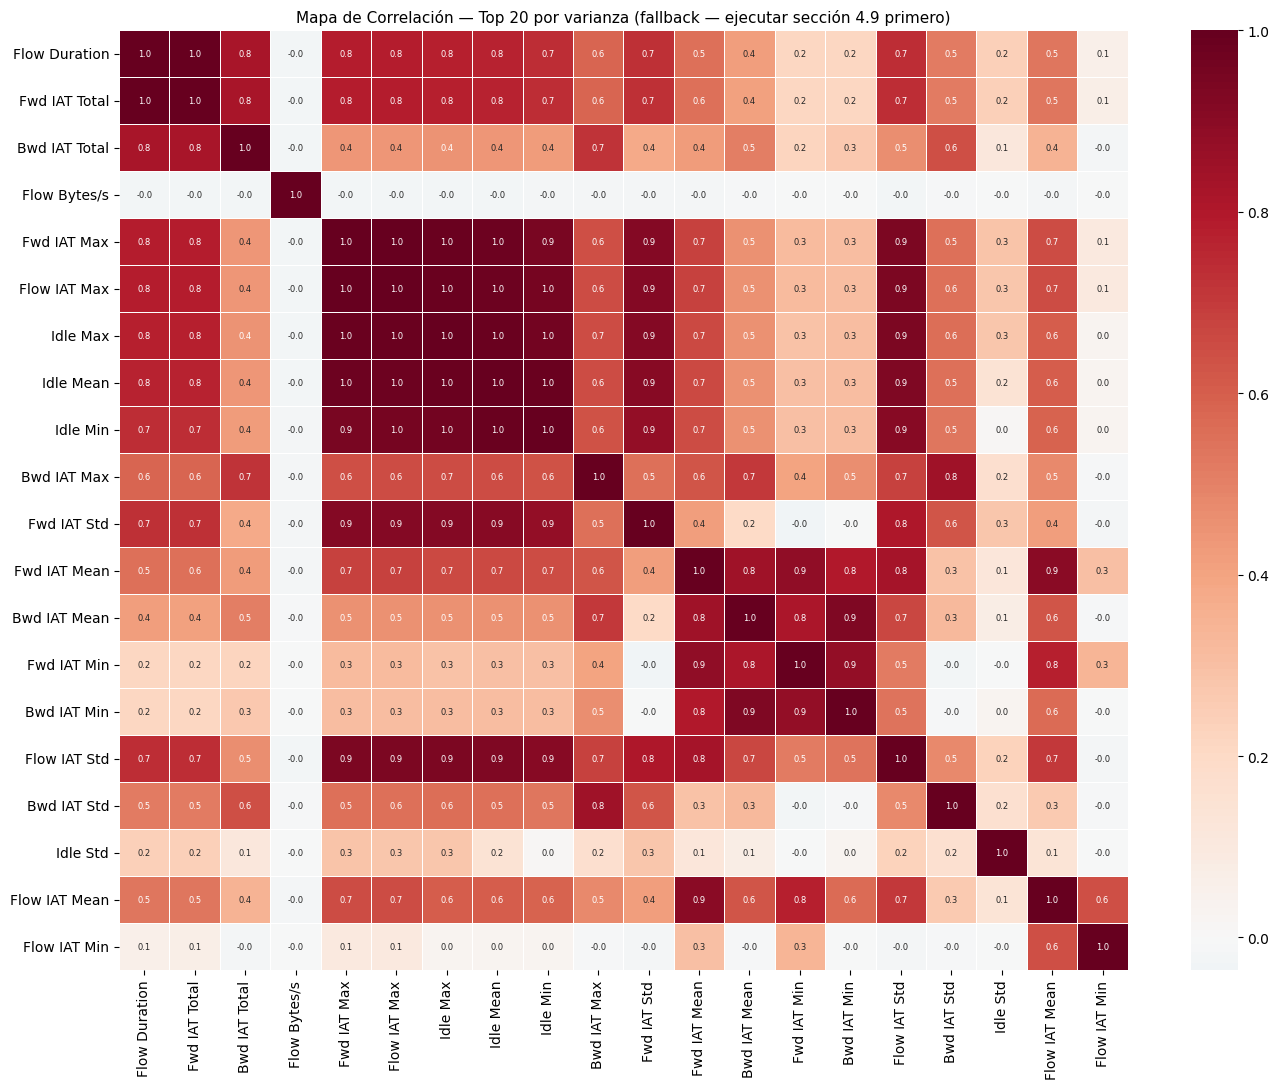

In [31]:
# Heatmap de correlación
if 'diff_relativa' in dir():
    top20_cols = diff_relativa.head(20).index.tolist()
    titulo_criterio = 'Top 20 por diferencia relativa de medianas (BENIGN vs Ataque)'
else:
    # Fallback: varianza (menos preciso, pero permite ejecutar la celda de forma aislada)
    varianza = df_clean[num_cols].var().sort_values(ascending=False)
    top20_cols = varianza.head(20).index.tolist()
    titulo_criterio = 'Top 20 por varianza (fallback — ejecutar sección 4.9 primero)'

# Filtrar columnas que existen en df_clean
top20_cols = [c for c in top20_cols if c in df_clean.columns]
corr_matrix = df_clean[top20_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0,
            annot=True, fmt='.1f', annot_kws={'size': 6},
            linewidths=0.5, ax=ax)
ax.set_title(f'Mapa de Correlación — {titulo_criterio}', fontsize=11)
plt.tight_layout()
plt.show()

In [32]:
# Pares con correlación muy alta
umbral = 0.95   # correlación > 95 % muy probablemente redundantes

alta_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= umbral:
            alta_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlación': round(val, 3)
            })

if alta_corr:
    print(f'Pares con correlación ≥ {umbral}:')
    print(pd.DataFrame(alta_corr).to_string(index=False))
else:
    print(f'No se encontraron pares con correlación ≥ {umbral} entre el top 20.')

Pares con correlación ≥ 0.95:
    Feature 1     Feature 2  Correlación
Flow Duration Fwd IAT Total         1.00
  Fwd IAT Max  Flow IAT Max         1.00
  Fwd IAT Max      Idle Max         0.99
  Fwd IAT Max     Idle Mean         0.98
 Flow IAT Max      Idle Max         0.99
 Flow IAT Max     Idle Mean         0.98
 Flow IAT Max      Idle Min         0.95
     Idle Max     Idle Mean         0.99
     Idle Max      Idle Min         0.96
    Idle Mean      Idle Min         0.99


**Preguntas y Respuestas**

**¿Qué criterio se usó para seleccionar las variables del heatmap?**

Se seleccionaron las top 20 variables por diferencia relativa de medianas entre BENIGN y ataques, que son las variables con mayor poder discriminativo para la tarea de clasificación. Este criterio es más relevante que seleccionar por varianza (criterio anterior), porque varianza alta no implica que la variable distinga entre clases: una variable puede tener dispersión enorme dentro de cada clase y aun así no separar bien BENIGN de ataques.

**¿Qué pares de variables están muy correlacionados?**

Las variables IAT (Inter-Arrival Time) en sus distintas estadísticas (media, máximo, std, total) muestran alta correlación entre sí, lo que es esperable: si el tiempo promedio entre paquetes es alto, el máximo y la desviación estándar también tienden a serlo. De forma similar, las métricas de longitud de paquete (mínimo, máximo, media) se correlacionan fuertemente. Esto indica redundancia entre subgrupos de variables que el modelo de selección (ANOVA K-Best) o la reducción (PCA) deberán resolver.

**¿Eliminamos las variables correlacionadas?**

No en esta etapa. La eliminación se hace en la fase de modelado, donde se comparará el rendimiento con todas las variables vs. la selección por ANOVA vs. PCA. Eliminar manualmente en el EDA introduce sesgo sin evidencia del impacto real sobre la métrica objetivo.

**¿Hay correlaciones negativas relevantes?**

En general son pocas y débiles en este dataset. Las métricas de red tienden a correlacionarse positivamente entre sí porque todas crecen cuando el volumen de tráfico aumenta.

##<font color="red"> 4.4 Obs: Aquí conviene seleccion de características, construcción de PCA.</font>

**Plan de tres representaciones** — se evaluarán en el notebook de entrenamiento:  
| Representación | Variables | Uso |
|:---|:---|:---|
| **Baseline** | Todas las variables limpias (~64) | Punto de referencia |
| **ANOVA K-Best** | Top 20 por F-score | Selección supervisada |
| **PCA** | Componentes que expliquen ≥95% varianza | Reducción no supervisada |

## 4.5 ¿Qué Distingue Cada Tipo de Ataque?

In [33]:
# Mediana de las top 10 variables por clase
# Esto muestra qué valores son típicos de cada tipo de ataque

# Elegir variables de red más interpretables
features_interes = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packet Length Max',
    'Bwd Packet Length Max', 'Flow IAT Mean', 'Fwd IAT Mean', 'Packet Length Mean'
]

# Filtrar solo las que existen después de la limpieza
features_interes = [f for f in features_interes if f in df_clean.columns]

tabla_mediana = df_clean.groupby('Label')[features_interes].median().round(1)

# Transponer para leer mejor (feature × clase)
pd.set_option('display.max_columns', None)
print('Mediana por clase para variables clave:')
display(tabla_mediana)

Mediana por clase para variables clave:


,Flow Duration,Total Fwd Packets,Total Backward Packets,Flow Bytes/s,Flow Packets/s,Fwd Packet Length Max,Bwd Packet Length Max,Flow IAT Mean,Fwd IAT Mean,Packet Length Mean
Label,,,,,,,,,,
BENIGN,31003.00,2.00,2.00,5149.80,122.50,40.00,84.00,10591.00,4.00,58.60
Botnet,70974.00,3.00,3.00,5022.00,101.30,6.00,6.00,11512.20,22994.70,6.00
Brute Force,4044135.00,9.00,11.00,279.00,5.90,18.50,34.00,174884.60,363542.90,11.20
DoS/DDoS,9447815.00,5.00,5.00,121.60,0.60,20.00,4380.00,2192840.60,2241613.50,797.00
PortScan,47.00,1.00,1.00,139534.90,42553.20,0.00,6.00,47.00,0.00,2.00
Rare Attack,101039258.00,45.00,40.00,1499.00,8.70,1271.00,6.00,115584.20,103271.20,184.40


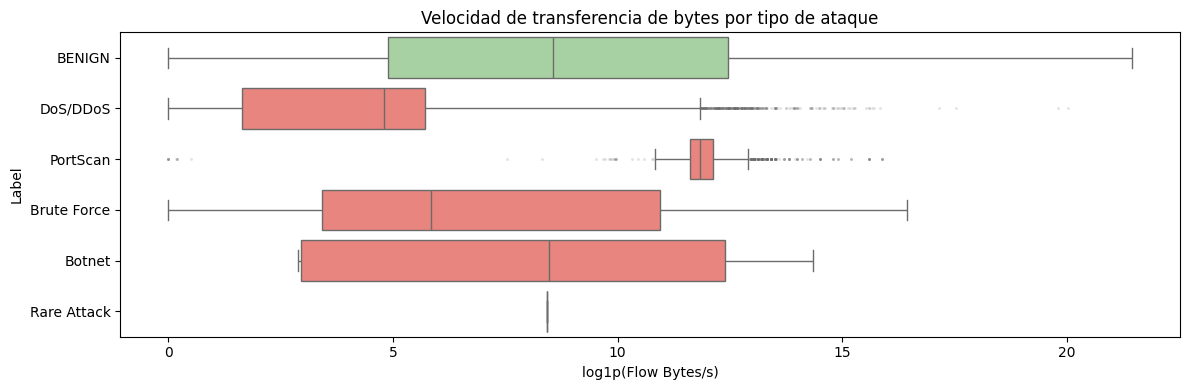

In [34]:
# Boxplot: Flow Bytes/s por tipo de ataque
# Flow Bytes/s es una de las variables más útiles para detectar DoS/DDoS

if 'Flow Bytes/s' in df_clean.columns:
    muestra = df_clean.sample(min(50_000, len(df_clean)), random_state=42).copy()
    muestra['log_bytes_s'] = np.log1p(muestra['Flow Bytes/s'].clip(lower=0))

    orden = df_clean['Label'].value_counts().index
    colors_list = [COLOR_BENIGNO if c == 'BENIGN' else COLOR_ATAQUE for c in orden]

    fig, ax = plt.subplots(figsize=(12, 4))
    sns.boxplot(data=muestra, x='log_bytes_s', y='Label', order=orden,
                palette=dict(zip(orden, colors_list)),
                flierprops={'marker':'.','alpha':0.2,'markersize':2})
    ax.set_xlabel('log1p(Flow Bytes/s)')
    ax.set_title('Velocidad de transferencia de bytes por tipo de ataque')
    plt.tight_layout()
    plt.show()

**Preguntas y Respuestas**

**¿Qué variables distinguen mejor cada tipo de ataque?**

En este gráfico, `Flow Bytes/s` (en escala log1p) muestra que **PortScan** es el ataque más fácil de identificar: su caja es muy estrecha y concentrada entre los valores 11 y 12, con poca dispersión, lo que indica un patrón de bytes muy consistente y separado del resto. **BENIGN** en cambio tiene la distribución más amplia de todas las clases, lo que refleja la variabilidad natural del tráfico legítimo.

**¿Hay ataques difíciles de separar del tráfico normal?**

Sí. **Rare Attack** es el caso más extremo: tiene tan pocas muestras que en el gráfico apenas aparece como una línea vertical sin caja visible, lo que significa que el modelo prácticamente no tendrá ejemplos suficientes para aprender su patrón. **Botnet** y **Brute Force** también presentan cajas que se solapan con el rango de BENIGN, lo que los hace más difíciles de detectar usando esta variable sola.

**¿Por qué DoS/DDoS muestra valores más bajos de lo esperado?**

Aunque intuitivamente un ataque de denegación de servicio debería generar un volumen enorme de bytes, la agrupación en la familia DoS/DDoS incluye variantes muy distintas: DoS Hulk es masivo, pero DoS Slowhttptest y DoS slowloris son ataques **lentos por diseño**, que agotan recursos del servidor enviando muy pocos bytes durante mucho tiempo. Al combinar todas estas variantes en una sola clase, la mediana de bytes/s baja considerablemente respecto a lo que mostraría Hulk o DDoS por separado.

**¿Qué conclusión podemos tener?**

Ninguna variable por sí sola separa perfectamente todas las familias de ataque. `Flow Bytes/s` es útil para identificar PortScan, pero no distingue bien entre DoS/DDoS, Brute Force, Botnet y BENIGN, cuyos rangos se solapan en este eje. El modelo necesitará combinar esta variable con métricas de duración, tiempo entre paquetes y conteo de paquetes para construir reglas de decisión efectivas.

## 4.6 Análisis del Desbalance de Clases

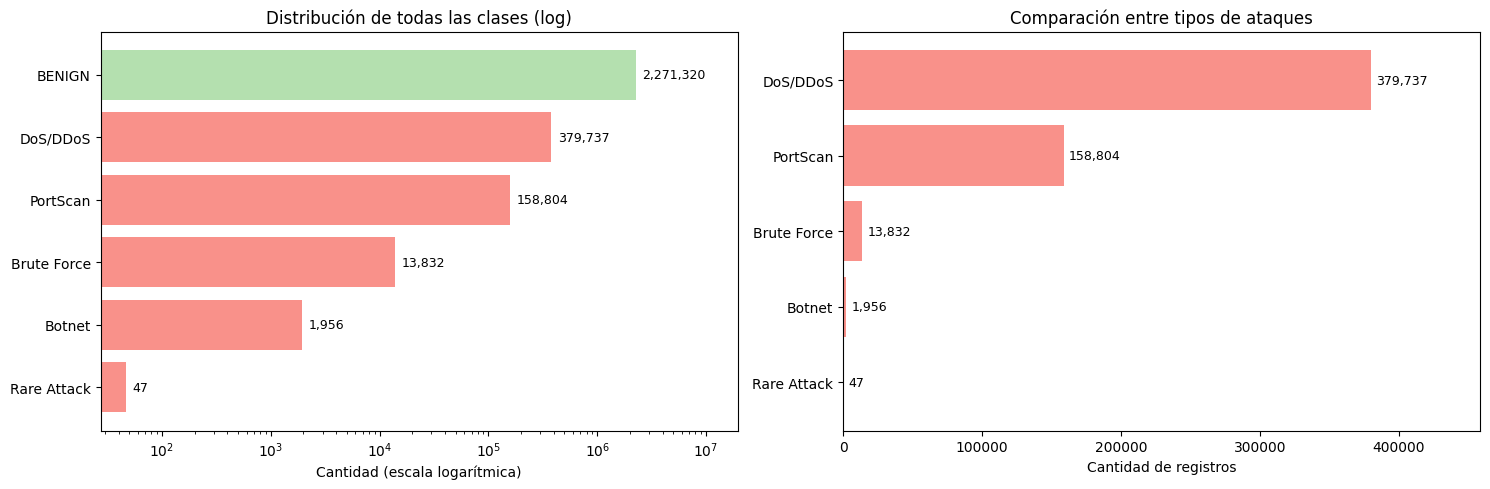


Ratio de desbalance (BENIGN / clase_más_rara):
 Clase más rara: Rare Attack (47 registros)
 BENIGN: 2,271,320 registros
 Ratio: 48326 : 1


In [35]:
# Visualizar el desbalance
counts = df_clean['Label'].value_counts()

# Separar benigno de ataques
benign_count = counts.get('BENIGN', 0)
attack_counts = counts.drop('BENIGN', errors='ignore')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# GRÁFICO 1: Todos juntos (escala logarítmica)
colores_g1 = [COLOR_BENIGNO if c == 'BENIGN' else COLOR_ATAQUE for c in counts.index]
bars0 = axes[0].barh(counts.index, counts.values, color=colores_g1, alpha=0.8)

axes[0].set_xscale('log')
axes[0].set_xlabel('Cantidad (escala logarítmica)')
axes[0].set_title('Distribución de todas las clases (log)')
axes[0].invert_yaxis()

# Añadir etiquetas (ajustado para escala logarítmica)
for bar in bars0:
    width = bar.get_width()
    if width > 0:
        # En escala logarítmica, sumamos un pequeño porcentaje al exponente/posición
        axes[0].text(width * 1.15, bar.get_y() + bar.get_height() / 2,
                     f'{int(width):,}', va='center', ha='left', fontsize=9)

# GRÁFICO 2: Solo los ataques (escala lineal)
bars1 = axes[1].barh(attack_counts.index, attack_counts.values, color=COLOR_ATAQUE, alpha=0.8)

axes[1].set_xlabel('Cantidad de registros')
axes[1].set_title('Comparación entre tipos de ataques')
axes[1].invert_yaxis()

# Añadir etiquetas (Escala lineal estándar)
# Conseguimos el límite máximo actual para dar un margen proporcional al texto
max_width = attack_counts.max()
for bar in bars1:
    width = bar.get_width()
    axes[1].text(width + (max_width * 0.01), bar.get_y() + bar.get_height() / 2,
                 f'{int(width):,}', va='center', ha='left', fontsize=9)

# Ajustar los límites de los ejes X para que los números no se corten al borde derecho
axes[0].set_xlim(right=axes[0].get_xlim()[1] * 5)
axes[1].set_xlim(right=axes[1].get_xlim()[1] * 1.15)

plt.tight_layout()
plt.show()

# Ratio de desbalance
print(f'\nRatio de desbalance (BENIGN / clase_más_rara):')
min_clase = counts.min()
print(f' Clase más rara: {counts.idxmin()} ({min_clase:,} registros)')
print(f' BENIGN: {benign_count:,} registros')
print(f' Ratio: {benign_count / min_clase:.0f} : 1')

**Preguntas y Respuestas**

**¿Qué tan grave es el desbalance?**

BENIGN representa 2.271.320 registros, aproximadamente el **80% del dataset**. La familia de ataque más rara es **Rare Attack** con solo 47 registros, que agrupa Heartbleed, Infiltration y Web Attack-Sql Injection. El ratio entre la clase más frecuente y la más rara es **48.326:1**, lo que significa que por cada ejemplo de Rare Attack el modelo verá casi cincuenta mil instancias de tráfico benigno. Incluso comparando con la familia más numerosa de ataques, DoS/DDoS con 379.737 registros, el desbalance interno entre familias de ataque es de **8.079:1**.

**¿Por qué es un problema?**

Un modelo entrenado sin corrección aprende rápidamente que predecir siempre BENIGN le da un accuracy del 80% sin detectar ni un solo ataque. Esto es exactamente lo opuesto a lo que necesita un IDS. El problema se agrava con Rare Attack: con solo 47 muestras totales, el modelo puede no ver ningún ejemplo de esa familia en varios pliegues de la validación cruzada, haciendo que su Recall sea 0%.

**¿Qué estrategia vamos a usar?**

El primer paso es entrenar con `class_weight='balanced_subsample'` en Random Forest, que penaliza más los errores en las familias raras en cada árbol de forma independiente. Para Rare Attack y Botnet, que tienen las menores cantidades de muestras, aplicaremos **SMOTE exclusivamente sobre el conjunto de entrenamiento**, generando registros sintéticos interpolando entre muestras reales. Nunca se aplica SMOTE al conjunto de prueba, ya que este debe representar la distribución real del tráfico. Finalmente, optimizaremos el umbral de decisión usando `predict_proba` para maximizar el Recall en las familias de ataque más peligrosas.

## 4.7 ¿Cómo se Distribuyen las Variables Más Importantes?

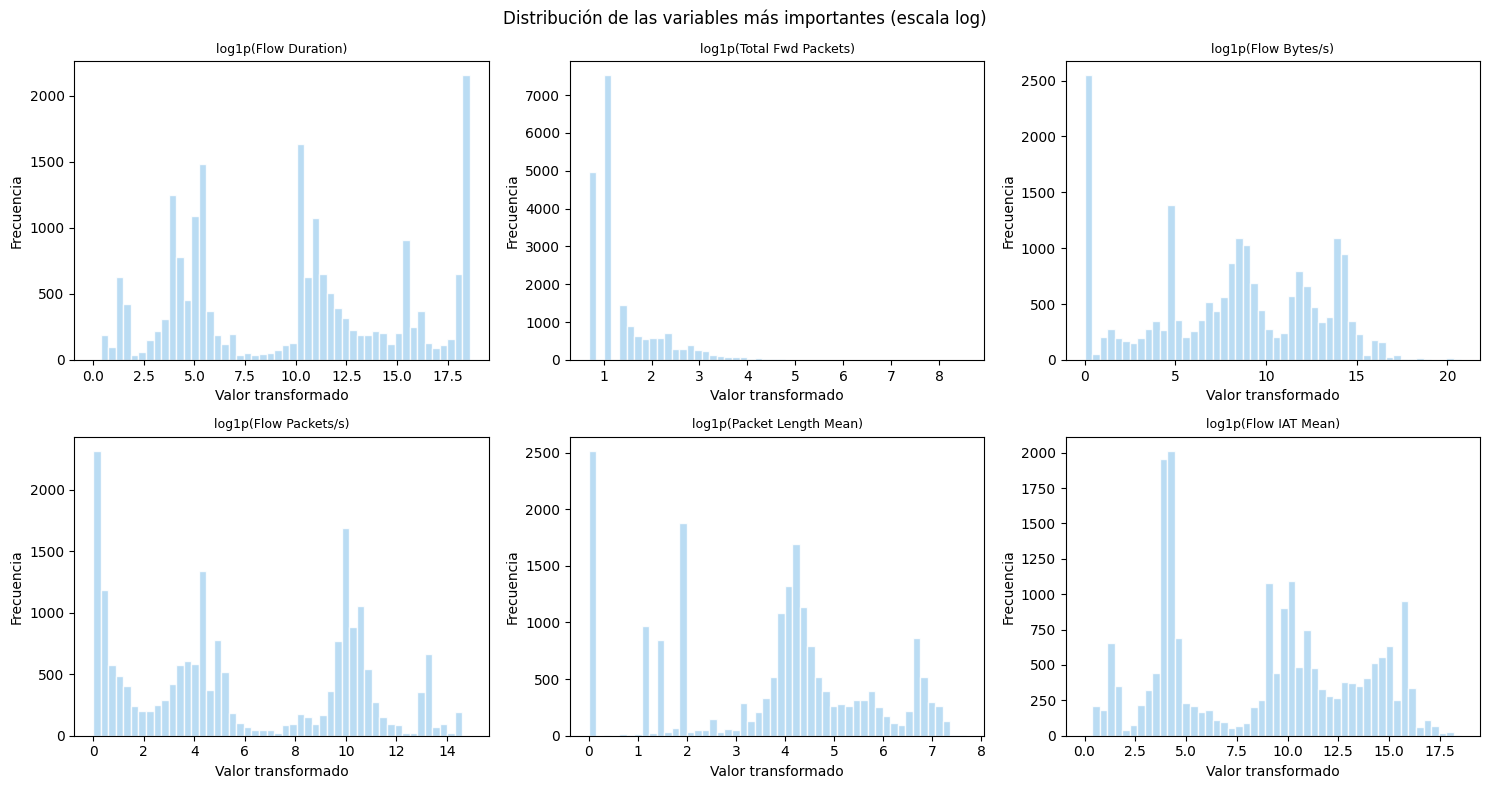

In [36]:
# Histogramas de las 6 variables más relevantes para un IDS
features_plot = [f for f in ['Flow Duration', 'Total Fwd Packets',
                              'Flow Bytes/s', 'Flow Packets/s',
                              'Packet Length Mean', 'Flow IAT Mean']
                 if f in df_clean.columns]

muestra = df_clean.sample(min(20_000, len(df_clean)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features_plot):
    # Aplicar log1p para comprimir la escala
    valores = np.log1p(muestra[col].clip(lower=0))
    axes[i].hist(valores, bins=50, color=COLOR_NEUTRO, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'log1p({col})', fontsize=9)
    axes[i].set_xlabel('Valor transformado')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de las variables más importantes (escala log)', fontsize=12)
plt.tight_layout()
plt.show()

**Preguntas y Respuestas**

**¿Tienen distribuciones normales?**

No. Ninguna variable sigue una distribución normal.

Lo que se observa en los seis gráficos es un patrón **multimodal**: existen múltiples picos separados en lugar de una campana única centrada. Por ejemplo, `Flow Duration` muestra acumulaciones en valores bajos (≈0-2), medios (≈10-12) y altos (≈18-19). `Total Fwd Packets` y `Flow Packets/s` tienen un pico dominante muy alto en valores cercanos a cero seguido de una distribución dispersa. `Packet Length Mean` y `Flow IAT Mean` presentan dos o tres grupos de concentración claramente separados. Esta multimodalidad refleja que el dataset mezcla poblaciones distintas: tráfico benigno y varios tipos de ataque, cada uno con su propio rango típico de valores.

**¿Por qué es importante saberlo?**

Algunos algoritmos como regresión logística o SVM asumen que los datos siguen distribuciones unimodales y aproximadamente simétricas; con distribuciones multimodales como estas su rendimiento se degrada. Además, la multimodalidad confirma que las variables contienen información discriminativa real: si benigno y los distintos tipos de ataque generan picos en rangos distintos, el modelo puede aprender a usar esas separaciones. Por eso los algoritmos basados en árboles como Random Forest o XGBoost son la elección correcta: parten el espacio de valores en umbrales y no asumen ninguna forma de distribución.

## 4.8 ¿Los Ataques Generan Más Tráfico en una Dirección?

¿La relación entre paquetes enviados (forward) y recibidos (backward) varía según el tipo de ataque?

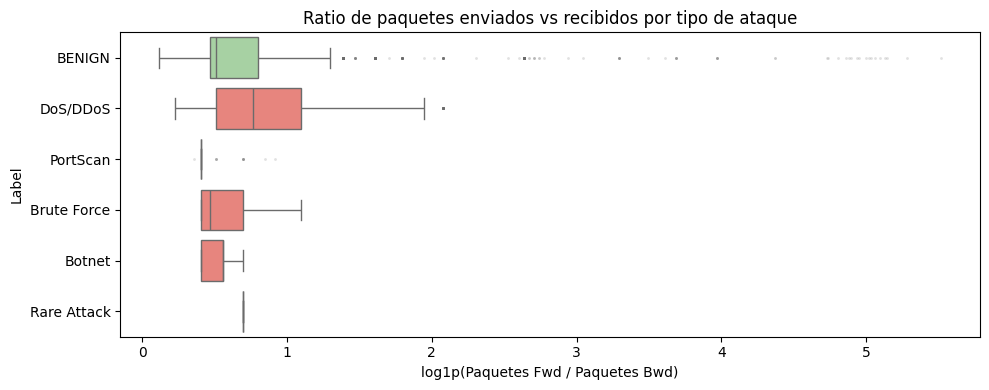

In [37]:
# Crear columna de ratio fwd/bwd (evitar división por cero)
if 'Total Fwd Packets' in df_clean.columns and 'Total Backward Packets' in df_clean.columns:
    muestra = df_clean.sample(min(30_000, len(df_clean)), random_state=42).copy()

    # Ratio: paquetes enviados / (paquetes recibidos + 1)
    muestra['ratio_fwd_bwd'] = muestra['Total Fwd Packets'] / (muestra['Total Backward Packets'] + 1)
    muestra['log_ratio'] = np.log1p(muestra['ratio_fwd_bwd'])

    orden = df_clean['Label'].value_counts().index
    colors_list = [COLOR_BENIGNO if c == 'BENIGN' else COLOR_ATAQUE for c in orden]

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(data=muestra, x='log_ratio', y='Label', order=orden,
                palette=colors_list,
                flierprops={'marker': '.', 'alpha': 0.2, 'markersize': 2})
    ax.set_xlabel('log1p(Paquetes Fwd / Paquetes Bwd)')
    ax.set_title('Ratio de paquetes enviados vs recibidos por tipo de ataque')
    plt.tight_layout()
    plt.show()

**Preguntas y Respuestas**

**¿Qué nos dice este ratio?**

Un ratio alto indica que se envían muchos más paquetes de los que se reciben. En este gráfico es **BENIGN** quien presenta el ratio más alto y con mayor dispersión: su caja se extiende hasta valores de log1p ≈ 1.5 y tiene outliers que llegan hasta 5-6, lo que refleja la variedad de conexiones legítimas (descargas, streaming, transferencias de archivos) donde una parte puede enviar mucho más que la otra. DoS/DDoS tiene una caja similar en posición pero más compacta, lo que indica un patrón más uniforme.

Este resultado es consistente con el análisis de `flag_ratio_extremo` de la sección 3.2: los ratios extremos (percentil 99 del ratio fwd/bwd) también se concentraban principalmente en tráfico benigno, no en ataques. Ambos análisis apuntan en la misma dirección: el ratio fwd/bwd es mayor en BENIGN que en los ataques a nivel de mediana y en los valores extremos.

**¿PortScan tiene un patrón especial?**

Sí, pero no el esperado. PortScan aparece con una caja prácticamente inexistente y solo algunos puntos dispersos muy cercanos a cero, lo que indica que sus flujos tienen un ratio fwd/bwd **extremadamente bajo y uniforme**, no alto. Esto se explica porque un escaneo de puertos envía una sonda mínima y espera la respuesta del servidor para determinar si el puerto está abierto; la comunicación es casi simétrica en cantidad de paquetes aunque muy corta.

**¿El tráfico BENIGN tiene un ratio equilibrado?**

No necesariamente. El gráfico muestra que BENIGN tiene la distribución más amplia y asimétrica de todas las clases, con muchos outliers hacia valores altos. Esto tiene sentido: el tráfico legítimo es heterogéneo e incluye desde navegación web (bastante simétrica) hasta descargas de archivos grandes (muy asimétricas en favor del forward). Botnet y Brute Force son quienes muestran ratios más bajos y concentrados, sugiriendo que esos ataques generan intercambios más parejos entre paquetes enviados y recibidos.

## 4.9 ¿Qué variables son las más diferentes entre Benigno y Ataque?

In [ ]:
# Comparar mediana de cada feature entre BENIGN y todos los ataques juntos
df_bin = df_clean.copy()
df_bin['es_ataque'] = (df_bin['Label'] != 'BENIGN').astype(int)

mediana_benigno = df_bin[df_bin['es_ataque'] == 0][num_cols].median()
mediana_ataque = df_bin[df_bin['es_ataque'] == 1][num_cols].median()

# Diferencia relativa (cuánto cambia en términos porcentuales)
diff_relativa = ((mediana_ataque - mediana_benigno) / (mediana_benigno.abs() + 1)).abs()
diff_relativa = diff_relativa.sort_values(ascending=False).head(15)

# Invertimos el orden aquí para que la barra más grande quede arriba en el gráfico
diff_grafico = diff_relativa.sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
diff_grafico.plot(kind='barh', ax=ax, color=COLOR_ATAQUE, alpha=0.85)

# Agregar grilla tenue (solo líneas verticales para guiar la lectura de las barras)
ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)
# Asegurar que las barras se dibujen por encima de la grilla
ax.set_axisbelow(True)

# Agregar las etiquetas con la cantidad al final de cada barra
for bar in ax.containers[0]:
    width = bar.get_width()
    # Usamos formato científico o decimal dependiendo de qué tan grandes sean tus diferencias
    # Si las diferencias son flotantes simples, puedes usar f'{width:.2f}' o f'{width:,.1f}'
    label_text = f'{width:,.2f}' if width >= 0.01 else f'{width:.2e}'

    ax.text(width, bar.get_y() + bar.get_height() / 2,
            f' {label_text}', # Un espacio en blanco al inicio separa el texto de la barra
            va='center', ha='left', fontsize=9)

# 3. Ajustar el límite de X agregando un 15% de margen a la derecha para que no se corten los números
ax.set_xlim(right=diff_grafico.max() * 1.15)

ax.set_xlabel('Diferencia relativa en medianas')
ax.set_title('Top 15 variables con mayor diferencia entre Benigno y Ataque')

plt.tight_layout()
plt.show()

**Preguntas y Respuestas**

**¿Qué nos dice este gráfico?**

Las barras más largas indican las variables donde la diferencia entre tráfico benigno y tráfico de ataque es mayor en términos de sus medianas. El resultado más llamativo es que el **top 5 está dominado completamente por variables IAT** (Inter-Arrival Time): `Fwd IAT Std`, `Fwd IAT Total`, `Fwd IAT Max`, `Fwd IAT Mean` y `Flow IAT Std`, con diferencias relativas de entre 675 y 1.723. Esto significa que los tiempos entre paquetes en dirección forward son la señal más diferenciadora entre tráfico benigno y ataque, muy por encima de variables como `Flow Bytes/s` o `Flow Packets/s` que intuitivamente parecerían más obvias.

**¿Cómo se interpreta la diferencia relativa?**

La diferencia relativa indica cuántas veces difiere la mediana del tráfico de ataque respecto a la del tráfico benigno. `Fwd IAT Std` con valor 1.722,83 significa que la variabilidad en los tiempos entre paquetes forward es 1.722 veces mayor en ataques que en tráfico normal. Esto tiene sentido: los ataques automatizados envían paquetes a intervalos muy regulares o extremadamente rápidos, mientras que el tráfico humano legítimo tiene tiempos entre paquetes mucho más irregulares y espaciados. En contraste, variables como `Flow Bytes/s` (0.97) o `Max Packet Length` (0.92) muestran diferencias menores a 1, lo que indica que en medianas los ataques no transfieren significativamente más bytes que el tráfico normal.

**¿Esto reemplaza a un modelo de machine learning?**

No. Este análisis univariado compara cada variable de forma independiente y solo usando la mediana. El modelo combinará simultáneamente todas estas variables y aprenderá interacciones entre ellas que este gráfico no puede capturar. Sin embargo, el resultado sí tiene implicancia directa en el modelado: las variables IAT deberían aparecer con alta importancia en el árbol de decisión y en Random Forest, y son candidatas prioritarias para el conjunto de selección ANOVA.

## 4.10 Análisis de las Clases Raras

In [ ]:
# Identificar clases raras (menos de 1000 registros)
counts = df_clean['Label'].value_counts()
clases_raras = counts[counts < 1000].index.tolist()

print('Clases con menos de 1000 muestras:')
for clase in clases_raras:
    print(f"- {clase}: {counts[clase]} registros")

if clases_raras:
    # Mostrar estadísticas de las clases raras
    df_raras = df_clean[df_clean['Label'].isin(clases_raras)]

    features_ver = [f for f in ['Flow Duration', 'Total Fwd Packets',
                                 'Flow Bytes/s', 'Packet Length Mean']
                    if f in df_clean.columns]

    for clase in clases_raras:
        print(f"\n> Estadísticas de la clase rara: {clase}")
        # Seleccionamos solo la clase actual y transponemos ( .T ) para leer mejor
        stats = df_raras[df_raras['Label'] == clase][features_ver].describe().T
        print(stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2).to_string())
        print(' ')

In [ ]:
# Comparar clases raras vs BENIGN en un scatter plot
if clases_raras and 'Flow Bytes/s' in df_clean.columns and 'Total Fwd Packets' in df_clean.columns:

    # Tomar muestra de BENIGN para comparar
    df_benign_muestra = df_clean[df_clean['Label'] == 'BENIGN'].sample(500, random_state=42)
    df_raras_muestra  = df_clean[df_clean['Label'].isin(clases_raras)]

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(
        np.log1p(df_benign_muestra['Total Fwd Packets'].clip(lower=0)),
        np.log1p(df_benign_muestra['Flow Bytes/s'].clip(lower=0)),
        c=COLOR_BENIGNO, alpha=0.4, s=20, label='BENIGN (muestra)'
    )

    colores_raras = ['#E74C3C', '#8E44AD', '#F39C12']
    for i, clase in enumerate(clases_raras):
        sub = df_raras_muestra[df_raras_muestra['Label'] == clase]
        ax.scatter(
            np.log1p(sub['Total Fwd Packets'].clip(lower=0)),
            np.log1p(sub['Flow Bytes/s'].clip(lower=0)),
            c=colores_raras[i % len(colores_raras)], s=60,
            label=f'{clase} ({len(sub)} registros)', zorder=5
        )

    ax.set_xlabel('log1p(Total Fwd Packets)')
    ax.set_ylabel('log1p(Flow Bytes/s)')
    ax.set_title('Clases raras vs Tráfico Benigno')
    ax.legend()
    plt.tight_layout()
    plt.show()


**Preguntas y Respuestas**

**¿Por qué analizar las clases raras por separado?**

Con solo 47 registros en total para Rare Attack (que agrupa Heartbleed, Infiltration y Web Attack-Sql Injection), cualquier modelo tiene una exposición mínima a estos patrones durante el entrenamiento. Analizarlos visualmente permite determinar si sus valores se solapan con el tráfico benigno o si ocupan regiones del espacio de features donde el modelo podría separarlos, lo que define qué estrategia de modelado tiene sentido aplicar.

**¿Se solapan con el tráfico benigno?**

Parcialmente. El gráfico muestra dos comportamientos distintos dentro de Rare Attack. La mayoría de los puntos rojos con pocos paquetes forward (log1p ≈ 1-4) caen dentro de la nube densa de puntos verdes, lo que indica solapamiento real con BENIGN en esa zona. Sin embargo, los puntos rojos con muchos paquetes forward (log1p > 6) ocupan una región donde el tráfico benigno es muy escaso, lo que sugiere que ese subgrupo sí podría ser distinguible. No se trata de una clase homogénea: la heterogeneidad interna de Rare Attack (tres tipos de ataque muy distintos agrupados juntos) explica esta dispersión.

**¿Qué hacemos con ellas en el modelado?**

Dado que ya se tomó la decisión de agruparlas en la familia Rare Attack, la estrategia más coherente es aplicar **SMOTE exclusivamente sobre el conjunto de entrenamiento** para aumentar su representación de 47 a un número que permita al modelo aprender algún patrón. Si después de entrenar el Recall para Rare Attack sigue siendo muy bajo (lo cual es probable dado el solapamiento observado), se puede evaluar si conviene mantenerla como clase separada o fusionarla con otra familia de ataque más numerosa.

## 4.11 Relación entre Variables Clave (Pairplot)

In [ ]:
# Pairplot con las 4 variables más importantes (muestra pequeña para no saturar)
features_pair = [f for f in ['Flow Bytes/s', 'Flow Packets/s',
                              'Total Fwd Packets', 'Flow Duration']
                 if f in df_clean.columns]

# Muestra estratificada: 200 por clase (máximo)
partes = []
for clase in df_clean['Label'].unique():
    sub = df_clean[df_clean['Label'] == clase]
    partes.append(sub.sample(min(200, len(sub)), random_state=42))
muestra_pair = pd.concat(partes, ignore_index=True)

# Aplicar log1p
for col in features_pair:
    muestra_pair[col] = np.log1p(muestra_pair[col].clip(lower=0))

# Simplificar etiquetas: BENIGN vs tipo de ataque
muestra_pair['Tipo'] = muestra_pair['Label'].apply(
    lambda x: 'BENIGN' if x == 'BENIGN' else 'ATAQUE'
)

pp = sns.pairplot(muestra_pair[features_pair + ['Tipo']],
                  hue='Tipo',
                  palette={'BENIGN': COLOR_BENIGNO, 'ATAQUE': COLOR_ATAQUE},
                  plot_kws={'alpha': 0.4, 's': 15},
                  diag_kind='kde')
pp.fig.suptitle('Pairplot — BENIGN vs ATAQUE (variables clave, escala log)', y=1.02, fontsize=12)
plt.show()


**Preguntas y Respuestas**

**¿Se puede separar BENIGN de ATAQUE con dos variables?**

Depende del par. El gráfico muestra situaciones muy distintas según la combinación:

- **`Flow Bytes/s` vs `Flow Packets/s`** (fila 1, columna 2): es la combinación con mayor separación visual. Los ataques forman una banda diagonal bien definida en valores altos de ambas variables, mientras que BENIGN se concentra cerca del origen. Sin embargo hay solapamiento en la zona media.
- **`Total Fwd Packets` vs cualquier otra variable** (columna 3 y fila 3): los ataques se concentran fuertemente en valores bajos de Total Fwd Packets (log1p ≈ 1-2), mientras que BENIGN se dispersa más. Hay cierta separación pero con mucho solapamiento.
- **`Flow Duration` vs `Flow Bytes/s` o `Flow Packets/s`** (fila 4): se ve una relación inversa clara — a mayor duración, menor tasa de bytes/paquetes — y los ataques tienden a ocupar el extremo de duraciones bajas con tasas altas, aunque sin separación limpia.

**¿Qué muestran las distribuciones diagonales (KDE)?**

Las curvas en la diagonal son las más reveladoras. `Flow Bytes/s` y `Flow Packets/s` muestran distribuciones **bimodales para los ataques** (dos picos bien marcados) y **unimodal para BENIGN** (un solo pico cerca de cero). Esto confirma que dentro de la categoría ATAQUE existen al menos dos subpoblaciones con comportamientos muy distintos en estas variables, probablemente ataques volumétricos como DoS/DDoS separados de ataques más silenciosos como Botnet. `Flow Duration` también muestra bimodalidad en ataques, con un grupo de flujos muy cortos y otro de duración media-alta.

**¿Qué implica esto para el modelado?**

Ningún par de variables por sí solo logra una separación limpia, pero la bimodalidad de los ataques es una señal positiva: indica que el modelo tiene estructura para aprender. Random Forest podrá explotar simultáneamente todas estas combinaciones de variables y construir regiones de decisión que ningún par aislado puede definir. La separación parcial visible en `Flow Bytes/s` vs `Flow Packets/s` anticipa que estas variables tendrán alta importancia en el modelo final.


## 4.12 Resumen de Variables Numéricas por Clase

In [ ]:
# Tabla resumen: promedio de las variables más importantes por clase
features_resumen = [f for f in ['Flow Duration', 'Total Fwd Packets',
                                 'Total Backward Packets', 'Flow Bytes/s',
                                 'Flow Packets/s', 'Packet Length Mean']
                    if f in df_clean.columns]

resumen_clase = df_clean.groupby('Label')[features_resumen].mean().round(1)

# Normalizar para comparar en la misma escala (0 a 1)
resumen_norm = (resumen_clase - resumen_clase.min()) / (resumen_clase.max() - resumen_clase.min() + 1e-9)

# Heatmap de comparación
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(resumen_norm, cmap='YlOrRd', annot=resumen_clase.round(0),
            fmt='.0f', annot_kws={'size': 7}, linewidths=0.5, ax=ax)
ax.set_title('Promedio de variables clave por clase (color = valor normalizado)', fontsize=11)
ax.set_xlabel('')
plt.tight_layout()
plt.show()

**Preguntas y Respuestas**

**¿Cómo leer este heatmap?**

El color indica el valor relativo dentro de cada columna: rojo oscuro significa que esa clase tiene el promedio más alto para esa variable, amarillo claro significa que tiene el promedio más bajo. Los números dentro de cada celda muestran el promedio real sin normalizar, lo que permite leer tanto la magnitud absoluta como la posición relativa entre clases simultáneamente.

**¿Qué patrones se ven claramente?**

- **Rare Attack** domina en `Flow Duration` (85.960.739), `Total Fwd Packets` (1.241) y `Total Backward Packets` (1.080), con los valores más altos por lejos en esas tres columnas. Esto refleja que los ataques agrupados en esta familia (Infiltration, Heartbleed) generan flujos muy largos con mucho intercambio de paquetes en ambas direcciones, comportamiento opuesto al de un ataque rápido.
- **DoS/DDoS** tiene el promedio más alto en `Flow Packets/s` (111.049) y el mayor `Packet Length Mean` (625), confirmando su naturaleza de saturación con paquetes grandes enviados a alta velocidad.
- **BENIGN** lidera en `Flow Bytes/s` (1.779.842), lo que a primera vista sorprende pero se explica porque el tráfico legítimo incluye transferencias de archivos y descargas que mueven grandes volúmenes de datos en conexiones de larga duración.
- **PortScan** tiene los valores más bajos en `Total Fwd Packets` (1) y `Total Backward Packets` (1), lo que confirma que solo envía sondeos mínimos sin transferir datos reales. Su `Packet Length Mean` de apenas 3 bytes es el más bajo de todas las clases.
- **Botnet** es la clase más parecida a BENIGN en casi todas las variables, con valores intermedios en todas las columnas, lo que anticipa que será la más difícil de separar durante el modelado.

**¿Por qué normalizamos los valores?**

Las variables tienen escalas radicalmente distintas: `Flow Duration` llega a 85 millones mientras que `Total Fwd Packets` está en el orden de las decenas. Sin normalización, la columna de `Flow Duration` concentraría todo el contraste visual y las diferencias en variables como `Packet Length Mean` serían imperceptibles. La normalización por columna lleva cada variable al rango 0-1 independientemente, permitiendo comparar patrones entre clases en todas las variables al mismo tiempo.


##<font color="red">4.13 Obs: Controlar las estrategias. Ver el sentido de normalizar en el modelo.</font>

La transformación `log1p` aplicada en este gráfico es **exclusivamente para visualización**. Permite comprimir la escala y hacer visible la estructura de los datos sin que los outliers extremos dominen el espacio del gráfico.

En el modelado esta transformación **no se aplica** a los algoritmos basados en árboles  (Árbol de Decisión, Random Forest) porque son invariantes a transformaciones monótonas:  un árbol que corta en `x > 500` es equivalente a uno que corta en `log1p(x) > 6.2`, el resultado es idéntico. Aplicar `log1p` al modelo sería trabajo innecesario y dificultaría la interpretación de los umbrales de decisión.

Para los casos donde sí se normaliza (PCA, Regresión Logística, SVM), se usará  **RobustScaler** sobre los valores originales sin `log1p`.

---

# 5. Conclusión del EDA

Luego del análisis, podemos sintetizar los principales hallazgos:

### Sobre la Calidad de los Datos

- El dataset original contenía **8 columnas constantes** (sin varianza), **5 columnas duplicadas** y **2 columnas con errores de medición graves** (valores negativos en duración), que fueron eliminadas.
- Se eliminaron ~2.867 filas con valores NaN (0.1% del total), provenientes de los infinitos en `Flow Bytes/s` y `Flow Packets/s`. El análisis previo a la eliminación confirmó que ninguna clase pierde más del 0.51% de sus registros y que las clases más raras (Heartbleed, Infiltration, Web Attack-Sql Injection) no tienen ningún NaN.
- El dataset limpio quedó con **2.825.696 filas y 66 columnas**.
- Se crearon variables flag de anomalías técnicas de red; se conservaron únicamente las que superan el baseline de ataques en ≥10 puntos porcentuales.

### Sobre la Variable Objetivo

- El dataset está **severamente desbalanceado**: BENIGN representa ~80% de los datos con 2.271.320 registros. El ratio entre la clase más frecuente y la familia más rara (Rare Attack, 47 registros) es de **48.326:1**.
- Las 15 clases originales fueron agrupadas en **6 familias** (BENIGN, DoS/DDoS, PortScan, Brute Force, Botnet, Rare Attack) para mejorar la masa estadística de las clases minoritarias. Ambas versiones del target se conservan para comparar en el modelado.

### Sobre las Variables

- Las distribuciones son **no normales y multimodales**: la presencia de múltiples picos en variables como `Flow Bytes/s`, `Flow Packets/s` y `Flow Duration` refleja que el dataset mezcla poblaciones con comportamientos distintos (tráfico normal y distintos tipos de ataque), lo cual es información discriminativa aprovechable por el modelo.
- El análisis de diferencia relativa de medianas reveló que las variables más discriminativas no son las más intuitivas: el **top 5 está dominado por variables IAT** (`Fwd IAT Std`, `Fwd IAT Total`, `Fwd IAT Max`, `Fwd IAT Mean`, `Flow IAT Std`), con diferencias de hasta 1.722 veces entre benigno y ataque. Variables como `Flow Bytes/s` o `Flow Packets/s`, aunque útiles, tienen diferencias relativas menores a 1.
- Se identificaron **31 variables con más del 50% de sus valores en cero**. Esto no implica error sino que muchas métricas de red (flags TCP, contadores URG) son naturalmente escasas.
- El análisis de correlación se realizó sobre las top 20 variables por diferencia relativa de medianas (variables más relevantes para clasificación), identificando alta redundancia entre variables IAT entre sí y entre métricas de longitud de paquete. Esto justifica aplicar PCA o selección de características antes del modelado.

### Sobre los Patrones de Ataque

- **DoS/DDoS**: se distinguen por el mayor promedio de `Flow Packets/s` (111.049) y `Packet Length Mean` (625). Al agrupar variantes lentas (slowloris, Slowhttptest) con rápidas (Hulk, DDoS), la mediana de `Flow Bytes/s` es más baja de lo esperado para un ataque volumétrico, lo que es un efecto de la agrupación y no un error del dataset.
- **PortScan**: el patrón más limpio de detectar. `Total Fwd Packets` y `Total Backward Packets` promedian apenas 1, con `Packet Length Mean` de 3 bytes, confirmando que solo sondea puertos sin transferir datos reales.
- **Rare Attack**: en el heatmap de promedios (sección 4.12), esta familia muestra los valores más extremos en `Flow Duration` (85.960.739), `Total Fwd Packets` (1.241) y `Total Backward Packets` (1.080), impulsados principalmente por Infiltration y Heartbleed. Sin embargo, el análisis de scatter (sección 4.10) reveló que Rare Attack es **heterogénea internamente**: la mayoría de sus puntos se solapan con BENIGN en el espacio `Total Fwd Packets` vs `Flow Bytes/s`, mientras que solo el subgrupo con muchos paquetes forward ocupa una región separable. Su dificultad principal es la **escasez crítica de muestras** (47 registros totales) combinada con esta heterogeneidad interna, lo que impide al modelo aprender un patrón confiable.
- **Botnet**: la familia más difícil de detectar. Sus promedios son intermedios en todas las variables y muy similares a BENIGN, sin ninguna métrica donde sobresalga claramente.
- **Brute Force**: tiempos entre paquetes bajos (`Fwd IAT Mean` pequeño), confirmado por su alta diferencia relativa en variables IAT.

El EDA demostró que el problema es tratable con las herramientas correctas. Los principales desafíos a resolver en la fase de modelado son el desbalance extremo de clases (especialmente Rare Attack con 47 muestras), la heterogeneidad interna de la familia DoS/DDoS al agrupar variantes lentas y rápidas, y la similitud de Botnet con el tráfico normal en prácticamente todas las variables analizadas.

## <font color="red">5.1 Obs: Volver a releer las sugerencias o estrategias. En base a para que utilizar estas variables, y como, ante la instancia de creación de modelo y optimización.</font>

**Estrategia de Modelado y Evaluación**

* **Métrica Principal:** Se priorizará el **Recall por clase** en lugar del Accuracy global.
* **Mitigación del Desbalance:** * Uso de `class_weight='balanced'` en los algoritmos.
* Aplicación de SMOTE **únicamente en el set de entrenamiento** para balancear las clases minoritarias (*Rare Attack* y *Botnet*).


* **Gestión de Outliers:** **No se eliminarán**. Los valores extremos en variables de red (como `Flow Bytes/s`) representan comportamientos de ataque volumétrico y son fundamentales para el aprendizaje del modelo.

**Selección de Features y Representaciones**

El análisis de medianas identificó los mejores predictores:

* **Prioridad Alta:** Variables de tiempo entre paquetes (`Fwd IAT Std`, `Fwd IAT Total`, etc.) y el `flag_paquete_gigante` (donde el 89.4% de los registros son ataques).
* **Prioridad Media:** `Flow Bytes/s`, `Flow Packets/s` y `flag_iat_muy_bajo`.
* **Prioridad Baja:** Variables con más del 50% de ceros.

**Sets de entrenamiento a evaluar:**

1. Todas las variables disponibles (baseline).
2. Selección de las 20 variables más relevantes mediante ANOVA.
3. Reducción de dimensionalidad mediante PCA conservando al menos el 95 % de la variabilidad.

**Preprocesamiento por Algoritmo**

Las variables presentan sesgo positivo alto y distribuciones multimodales, lo que define el tratamiento según el modelo:

- Los modelos basados en árboles (Decision Tree y Random Forest) utilizarán los datos originales.
- Regresión Logística y SVM emplearán RobustScaler para reducir el impacto de los outliers.
- PCA se aplicará después del escalado.